# DIANA V2 — Chapter 4: Results and Discussion
### Publication- & Defense-Quality Results Notebook

**Project:** Diabetes risk assessment for post-menopausal women (NHANES 2009–2023)
**Tasks analysed:**
1. **Binary classification** — *Normal* vs *At-Risk* (pre-diabetic + diabetic) using 9 non-circular, LR-safe features.
2. **Weighted K-Means clustering (K=4)** — Ahlqvist-style metabolic subtypes (SIRD, SIDD, MOD, MARD).

This notebook is **reproducible and presentation-ready**. It:
- Loads the canonical processed dataset (`diana_dataset_final.csv`).
- Reconstructs the model-ready feature matrix using the project's documented feature engineering.
- Performs dataset inspection, EDA, feature-selection (information gain), multi-model training,
  evaluation, clustering analysis, and SHAP explainability.
- Exports every figure at **300 DPI** to `results_figures/`, every table to `results_tables/`
  (CSV + Excel), and a narrative summary to `results_reports/`.

> **Clinical disclaimer.** The models here are *screening* tools, not diagnostic devices. Risk
> scores are probabilities requiring qualified clinical review (per WHO AI-for-Health guidance).

---
### How to run
`Kernel → Restart & Run All`. No manual editing is required if the notebook lives anywhere inside
the `DianaV2` project tree (paths are auto-detected). Optional libraries (XGBoost, LightGBM, UMAP,
Yellowbrick, SHAP, openpyxl) are detected gracefully — missing ones simply skip their section.


## 1. Environment, Configuration & Reproducibility

We fix a global random seed, define a consistent publication plotting style (300-DPI export,
readable fonts, titled/labelled axes), auto-detect the project root, and create the three output
folders. A single `save_fig()` helper guarantees every figure is exported as PNG with a numbered,
descriptive filename.


In [1]:
import os
import sys
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ----------------------------------------------------------------------
# Auto-detect the DianaV2 project root (works from any sub-folder)
# ----------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd()

def _find_project_root(start: Path) -> Path:
    p = start
    rel = Path("data") / "nhanes" / "processed" / "diana_dataset_final.csv"
    for _ in range(8):
        if (p / rel).exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    return start

PROJECT_ROOT = _find_project_root(NOTEBOOK_DIR)
DATA_PATH      = PROJECT_ROOT / "data" / "nhanes" / "processed" / "diana_dataset_final.csv"
CLUSTERED_PATH = PROJECT_ROOT / "data" / "nhanes" / "processed" / "diana_clustered_final.csv"

# ----------------------------------------------------------------------
# Output directories
# ----------------------------------------------------------------------
FIG_DIR = NOTEBOOK_DIR / "results_figures"
TAB_DIR = NOTEBOOK_DIR / "results_tables"
REP_DIR = NOTEBOOK_DIR / "results_reports"
for _d in (FIG_DIR, TAB_DIR, REP_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Dataset      :", DATA_PATH, "(exists:", DATA_PATH.exists(), ")")
print("Figures  ->", FIG_DIR)
print("Tables   ->", TAB_DIR)
print("Reports  ->", REP_DIR)


Project root : c:\Users\Neoron\Downloads\DianaV2
Dataset      : c:\Users\Neoron\Downloads\DianaV2\data\nhanes\processed\diana_dataset_final.csv (exists: True )
Figures  -> c:\Users\Neoron\Downloads\DianaV2\results_figures
Tables   -> c:\Users\Neoron\Downloads\DianaV2\results_tables
Reports  -> c:\Users\Neoron\Downloads\DianaV2\results_reports


In [2]:
# ----------------------------------------------------------------------
# Publication plotting style
# ----------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "medium",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.fontsize": 11,
    "legend.frameon": True,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# Consistent colour scheme
C_NORMAL, C_RISK = "#2E86AB", "#E4572E"
CLASS_COLORS = [C_NORMAL, C_RISK]
SUBTYPE_COLORS = {"SIRD": "#D7263D", "SIDD": "#F46036",
                  "MOD": "#2E86AB", "MARD": "#5B8C5A"}
SEQ_CMAP = "viridis"
CORR_CMAP = "RdBu_r"

# Numbered figure export helper
_FIG_INDEX = {"n": 0}
FIGURE_MANIFEST = []

def save_fig(fig, name, caption=""):
    '''Save a Matplotlib figure as a numbered 300-DPI PNG and log it.'''
    _FIG_INDEX["n"] += 1
    fname = f"fig_{_FIG_INDEX['n']:02d}_{name}.png"
    path = FIG_DIR / fname
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    FIGURE_MANIFEST.append({"index": _FIG_INDEX["n"], "file": fname, "caption": caption})
    print(f"  [figure saved] {fname}")
    return path

print("Plotting style configured. save_fig() ready.")


Plotting style configured. save_fig() ready.


In [3]:
# ----------------------------------------------------------------------
# Optional dependency detection (graceful degradation)
# ----------------------------------------------------------------------
def _has(modname):
    try:
        __import__(modname)
        return True
    except Exception:
        return False

HAS_SHAP     = _has("shap")
HAS_XGB      = _has("xgboost")
HAS_LGBM     = _has("lightgbm")
HAS_UMAP     = _has("umap")
HAS_YB       = _has("yellowbrick")
HAS_NETWORKX = _has("networkx")
HAS_OPENPYXL = _has("openpyxl")

print("Optional libraries detected:")
for lib, ok in [("shap", HAS_SHAP), ("xgboost", HAS_XGB), ("lightgbm", HAS_LGBM),
                ("umap-learn", HAS_UMAP), ("yellowbrick", HAS_YB),
                ("networkx", HAS_NETWORKX), ("openpyxl", HAS_OPENPYXL)]:
    print(f"  {'OK ' if ok else '-- '} {lib}")


Optional libraries detected:
  OK  shap
  OK  xgboost
  OK  lightgbm
  --  umap-learn
  --  yellowbrick
  OK  networkx
  OK  openpyxl


## 2. Dataset Loading & Feature Construction

We load the canonical processed dataset and reconstruct the **model-ready feature matrix** exactly
as the production training pipeline does:

- **Target** `at_risk` = `1` if `diabetes_label >= 1` (pre-diabetic *or* diabetic), else `0` (Normal).
- **9 screening features** (deliberately *exclude* HbA1c & FBS — they define the label, so including
  them would cause circular leakage):
  `bmi, triglycerides, ldl, hdl, age, waist_circumference, smoking_encoded, activity_encoded, alcohol_encoded`.
- **Ordinal encodings** follow the documented mappings (Unknown → middle/`1`).
- **Grouping variable** `cycle` (NHANES survey wave) is used for group-aware validation so that
  no participant wave leaks between train and test.


In [4]:
# ----------------------------------------------------------------------
# Load raw processed dataset
# ----------------------------------------------------------------------
df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.name}: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")

# ----------------------------------------------------------------------
# Documented ordinal encodings (Unknown -> middle category = 1)
# ----------------------------------------------------------------------
SMOKING_MAP  = {"Never": 0, "Former": 1, "Current": 2}
ACTIVITY_MAP = {"Sedentary": 0, "Moderate": 1, "Active": 2}
ALCOHOL_MAP  = {"Never": 0, "None": 0, "Light": 1, "Moderate": 2, "Heavy": 3}

df = df_raw.copy()
df["smoking_encoded"]  = df["smoking_status"].map(SMOKING_MAP).fillna(1).astype(int)
df["activity_encoded"] = df["physical_activity"].map(ACTIVITY_MAP).fillna(1).astype(int)
df["alcohol_encoded"]  = df["alcohol_use"].map(ALCOHOL_MAP).fillna(1).astype(int)

# ----------------------------------------------------------------------
# Binary target: Normal (0) vs At-Risk (1)
# ----------------------------------------------------------------------
TARGET = "at_risk"
df[TARGET] = (df["diabetes_label"].astype(float) >= 1).astype(int)
TARGET_NAMES = {0: "Normal", 1: "At-Risk"}

# ----------------------------------------------------------------------
# Feature groups
# ----------------------------------------------------------------------
CONT_FEATURES = ["bmi", "triglycerides", "ldl", "hdl", "age", "waist_circumference"]
ORD_FEATURES  = ["smoking_encoded", "activity_encoded", "alcohol_encoded"]
FEATURES      = CONT_FEATURES + ORD_FEATURES
GROUP_COL     = "cycle"

# Clustering uses the 6 continuous biomarkers with expert weights
CLUSTER_FEATURES = ["bmi", "triglycerides", "ldl", "hdl", "age", "waist_circumference"]
CLUSTER_WEIGHTS  = {"bmi": 1.5, "triglycerides": 2.0, "ldl": 2.5,
                    "hdl": 1.2, "age": 1.0, "waist_circumference": 2.0}

# Pretty display names for plots
PRETTY = {
    "bmi": "BMI (kg/m\u00b2)", "triglycerides": "Triglycerides (mg/dL)",
    "ldl": "LDL (mg/dL)", "hdl": "HDL (mg/dL)", "age": "Age (years)",
    "waist_circumference": "Waist Circ. (cm)", "smoking_encoded": "Smoking (ord.)",
    "activity_encoded": "Activity (ord.)", "alcohol_encoded": "Alcohol (ord.)",
}

print("Target distribution:")
print(df[TARGET].value_counts().rename(index=TARGET_NAMES).to_string())
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"Group column: {GROUP_COL} -> cycles: {sorted(df[GROUP_COL].unique())}")


Loaded diana_dataset_final.csv: 1376 rows x 23 columns
Target distribution:
at_risk
At-Risk    734
Normal     642

Features (9): ['bmi', 'triglycerides', 'ldl', 'hdl', 'age', 'waist_circumference', 'smoking_encoded', 'activity_encoded', 'alcohol_encoded']
Group column: cycle -> cycles: ['2009-2010', '2011-2012', '2013-2014', '2015-2016', '2017-2018', '2021-2023']


## 3. Data Exploration & Inspection

Automatic profiling: shape, feature list, dtypes, missing-value summary, class distribution, and
numerical-feature statistics. Figures produced:
**(3.1)** missing-value heatmap, **(3.2)** class-distribution chart, **(3.3)** numerical feature
distributions.


In [5]:
# ----------------------------------------------------------------------
# 3.0 Tabular dataset profile
# ----------------------------------------------------------------------
print("=" * 70)
print("DATASET SHAPE :", df_raw.shape)
print("=" * 70)

print("\n--- DTYPES ---")
print(df_raw.dtypes.to_string())

print("\n--- NUMERICAL FEATURE STATISTICS (model features) ---")
desc = df[FEATURES].describe().T
display(desc.round(2))

print("\n--- MISSING VALUE SUMMARY ---")
miss = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)
display(miss[miss["missing_count"] > 0])

print("\n--- CLASS DISTRIBUTION ---")
cls = df[TARGET].value_counts().rename(index=TARGET_NAMES)
cls_pct = (df[TARGET].value_counts(normalize=True) * 100).round(1).rename(index=TARGET_NAMES)
display(pd.DataFrame({"count": cls, "percent": cls_pct}))


DATASET SHAPE : (1376, 23)

--- DTYPES ---
SEQN                       float64
age                        float64
hba1c                      float64
fbs                        float64
bmi                        float64
total_cholesterol          float64
ldl                        float64
hdl                        float64
triglycerides              float64
systolic                   float64
diastolic                  float64
waist_circumference        float64
fasting_insulin            float64
crp                        float64
family_history_diabetes    float64
smoking_status              object
physical_activity           object
alcohol_use                 object
cycle                       object
diabetes_status             object
diabetes_label               int64
menopausal_status           object
has_outlier                   bool

--- NUMERICAL FEATURE STATISTICS (model features) ---


,count,mean,std,min,25%,50%,75%,max
bmi,1365.0,31.09,7.98,13.6,25.46,29.80,35.70,74.8
triglycerides,1340.0,127.28,83.05,24.0,75.00,106.00,155.00,876.0
ldl,1321.0,125.02,37.22,24.0,100.00,123.00,148.00,375.0
hdl,1348.0,58.88,16.70,23.0,47.00,56.00,67.25,142.0
age,1376.0,54.59,4.11,45.0,52.00,55.00,58.00,60.0
waist_circumference,1348.0,101.53,16.74,66.3,89.57,100.05,112.12,169.0
smoking_encoded,1376.0,0.65,0.81,0.0,0.00,0.00,1.00,2.0
activity_encoded,1376.0,0.98,0.73,0.0,0.00,1.00,2.00,2.0
alcohol_encoded,1376.0,0.87,0.84,0.0,0.00,1.00,1.00,3.0



--- MISSING VALUE SUMMARY ---


,missing_count,missing_pct
crp,664,48.26
fasting_insulin,441,32.05
family_history_diabetes,265,19.26
systolic,82,5.96
diastolic,82,5.96
ldl,55,4.00
triglycerides,36,2.62
waist_circumference,28,2.03
total_cholesterol,28,2.03
hdl,28,2.03



--- CLASS DISTRIBUTION ---


,count,percent
at_risk,,
At-Risk,734,53.3
Normal,642,46.7


  [figure saved] fig_01_missing_value_heatmap.png


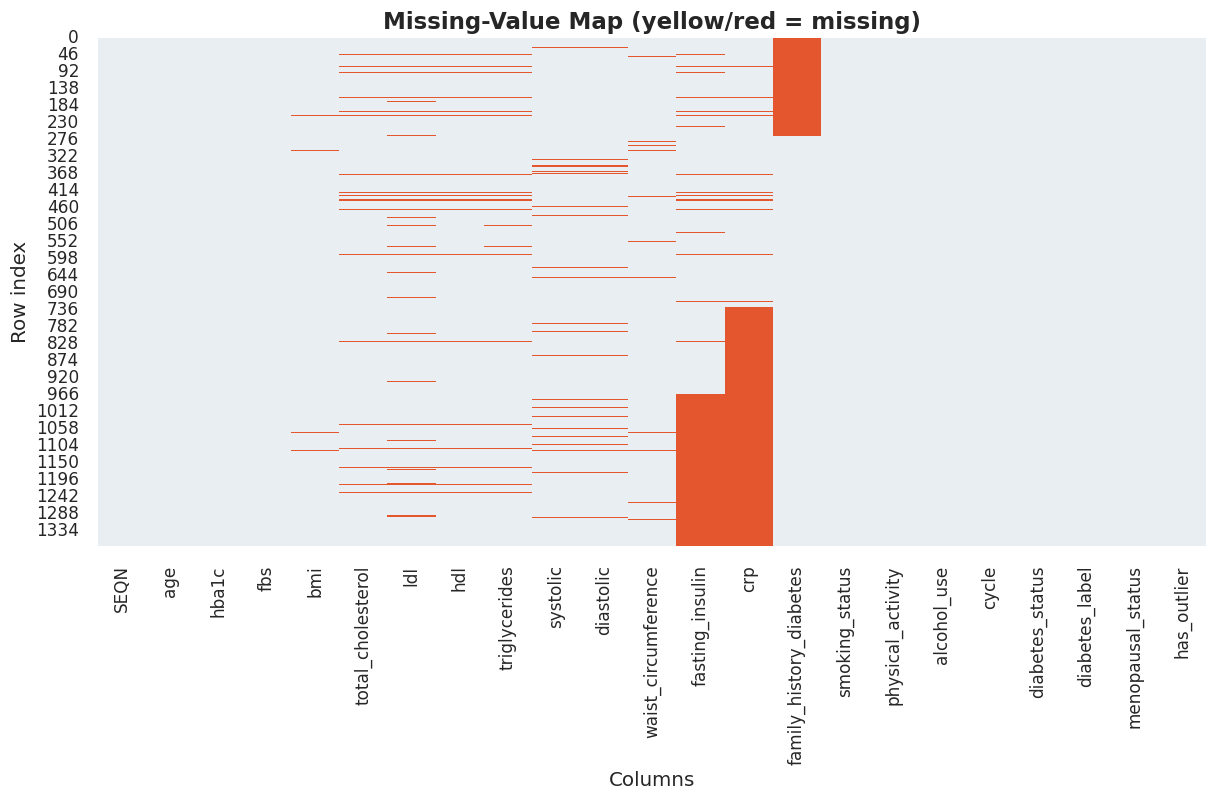

In [6]:
# ----------------------------------------------------------------------
# 3.1 Missing-value heatmap
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(df_raw.isna(), cbar=False, cmap=["#E8EEF2", "#E4572E"], ax=ax)
ax.set_title("Missing-Value Map (yellow/red = missing)")
ax.set_xlabel("Columns")
ax.set_ylabel("Row index")
plt.xticks(rotation=90)
save_fig(fig, "missing_value_heatmap", "Missing-value map across all raw columns.")
plt.show()


  [figure saved] fig_02_class_distribution.png


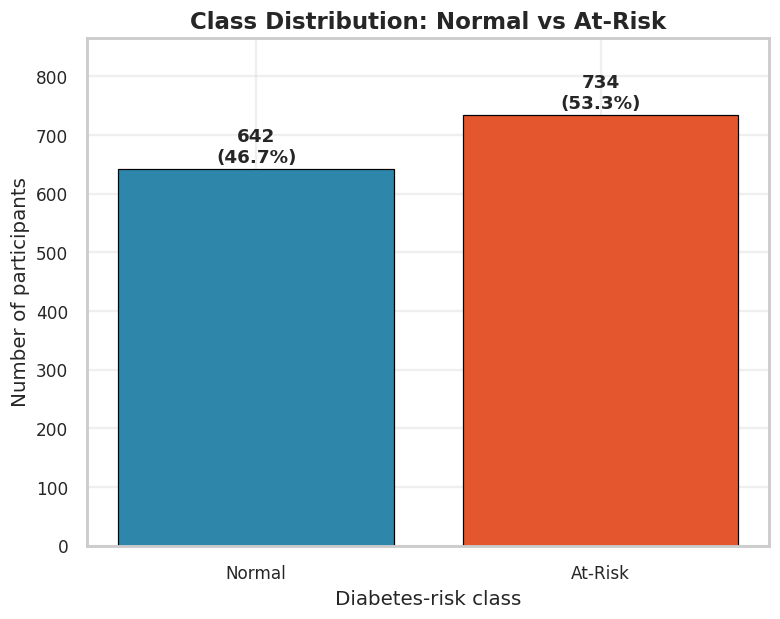

In [7]:
# ----------------------------------------------------------------------
# 3.2 Class-distribution chart
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
counts = df[TARGET].value_counts().sort_index()
bars = ax.bar([TARGET_NAMES[i] for i in counts.index], counts.values,
              color=CLASS_COLORS, edgecolor="black", linewidth=0.8)
for b, v in zip(bars, counts.values):
    pct = 100 * v / counts.sum()
    ax.text(b.get_x() + b.get_width() / 2, v + 5, f"{v}\n({pct:.1f}%)",
            ha="center", va="bottom", fontweight="bold")
ax.set_title("Class Distribution: Normal vs At-Risk")
ax.set_ylabel("Number of participants")
ax.set_xlabel("Diabetes-risk class")
ax.set_ylim(0, counts.max() * 1.18)
save_fig(fig, "class_distribution", "Binary target class balance.")
plt.show()


  [figure saved] fig_03_numerical_feature_distributions.png


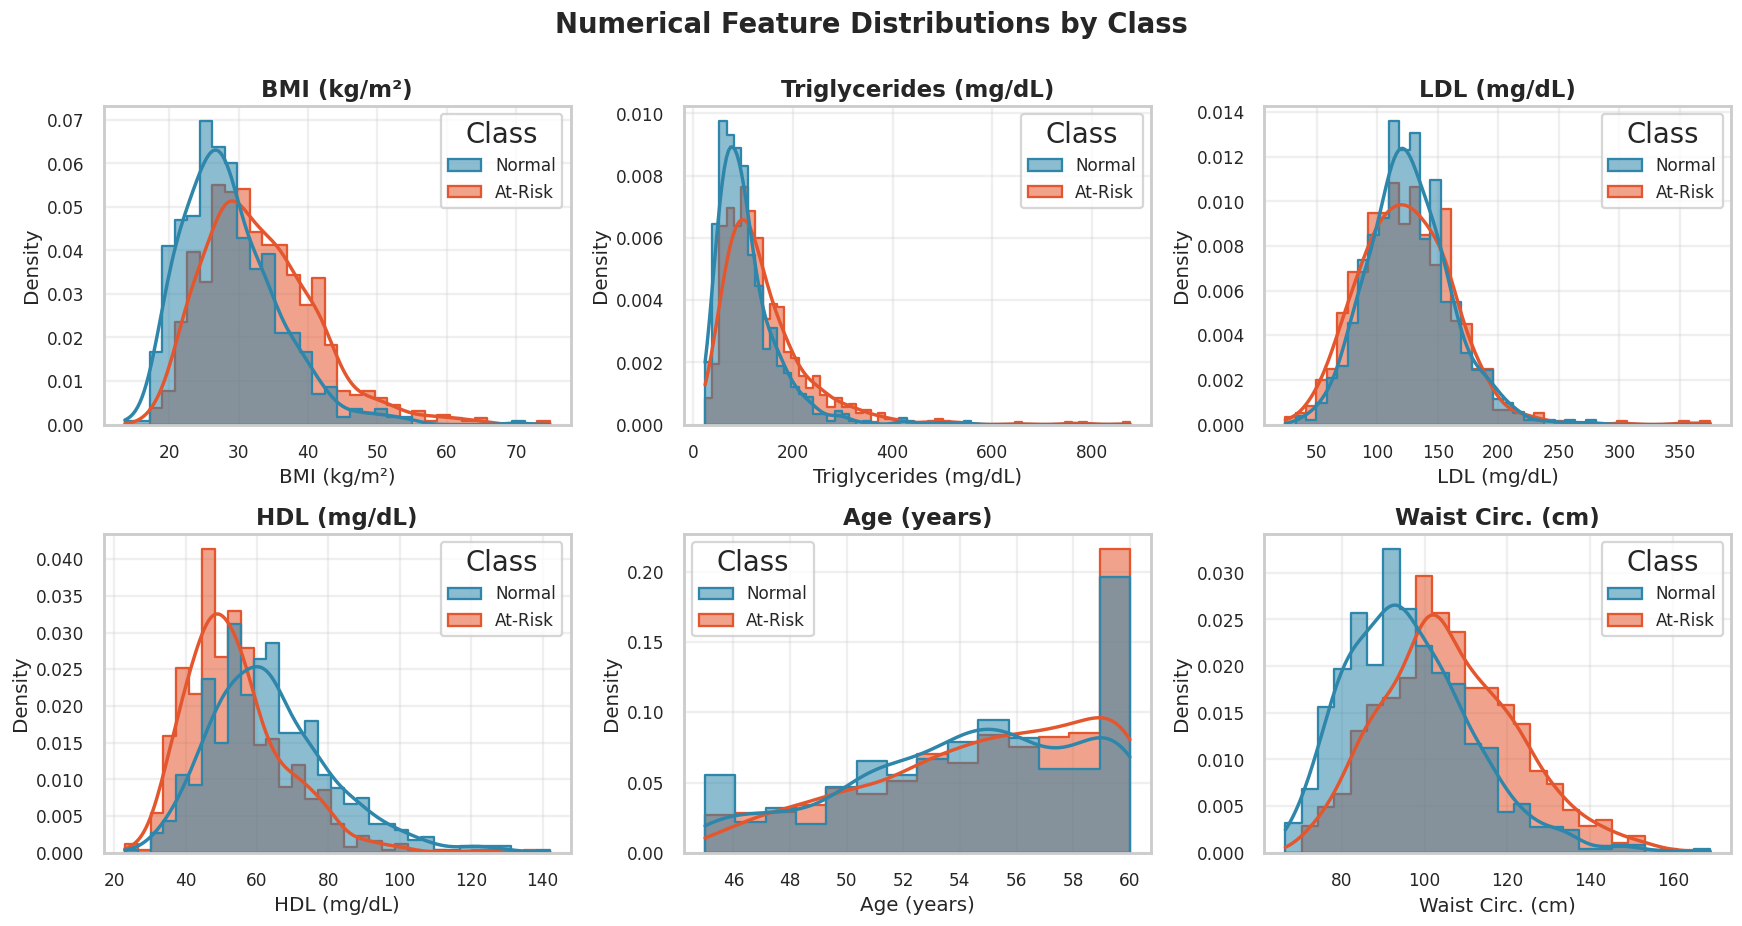

In [8]:
# ----------------------------------------------------------------------
# 3.3 Numerical feature distribution plots (grid)
# ----------------------------------------------------------------------
ncols = 3
nrows = math.ceil(len(CONT_FEATURES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows))
axes = np.array(axes).ravel()
for i, feat in enumerate(CONT_FEATURES):
    ax = axes[i]
    sns.histplot(data=df, x=feat, hue=df[TARGET].map(TARGET_NAMES),
                 palette=CLASS_COLORS, kde=True, ax=ax, alpha=0.55,
                 element="step", stat="density", common_norm=False)
    ax.set_title(PRETTY.get(feat, feat))
    ax.set_xlabel(PRETTY.get(feat, feat))
    leg = ax.get_legend()
    if leg:
        leg.set_title("Class")
for j in range(len(CONT_FEATURES), len(axes)):
    axes[j].axis("off")
fig.suptitle("Numerical Feature Distributions by Class", fontsize=18, fontweight="bold", y=1.0)
fig.tight_layout()
save_fig(fig, "numerical_feature_distributions", "Continuous biomarker distributions split by class.")
plt.show()


## 4. Exploratory Data Analysis (EDA)

Correlation structure (Pearson **and** Spearman), a pairplot of the most class-discriminative
features, per-feature histograms, and boxplots for outlier detection.


  [figure saved] fig_04_correlation_pearson.png


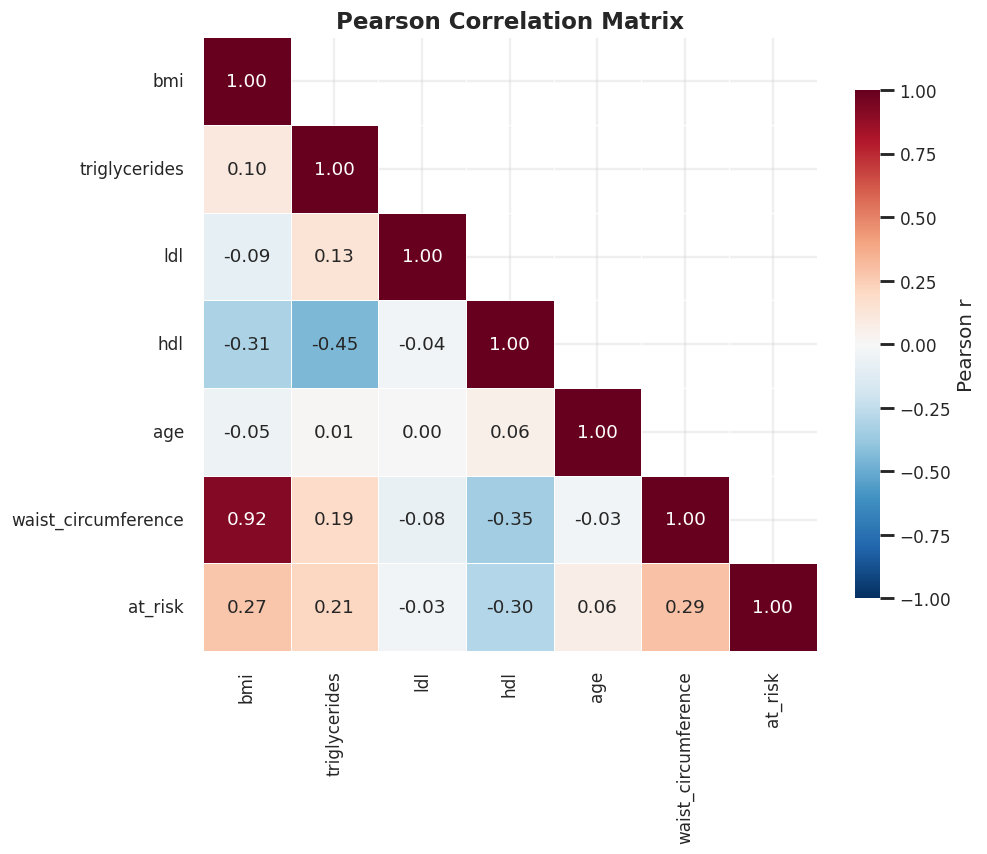

  [figure saved] fig_05_correlation_spearman.png


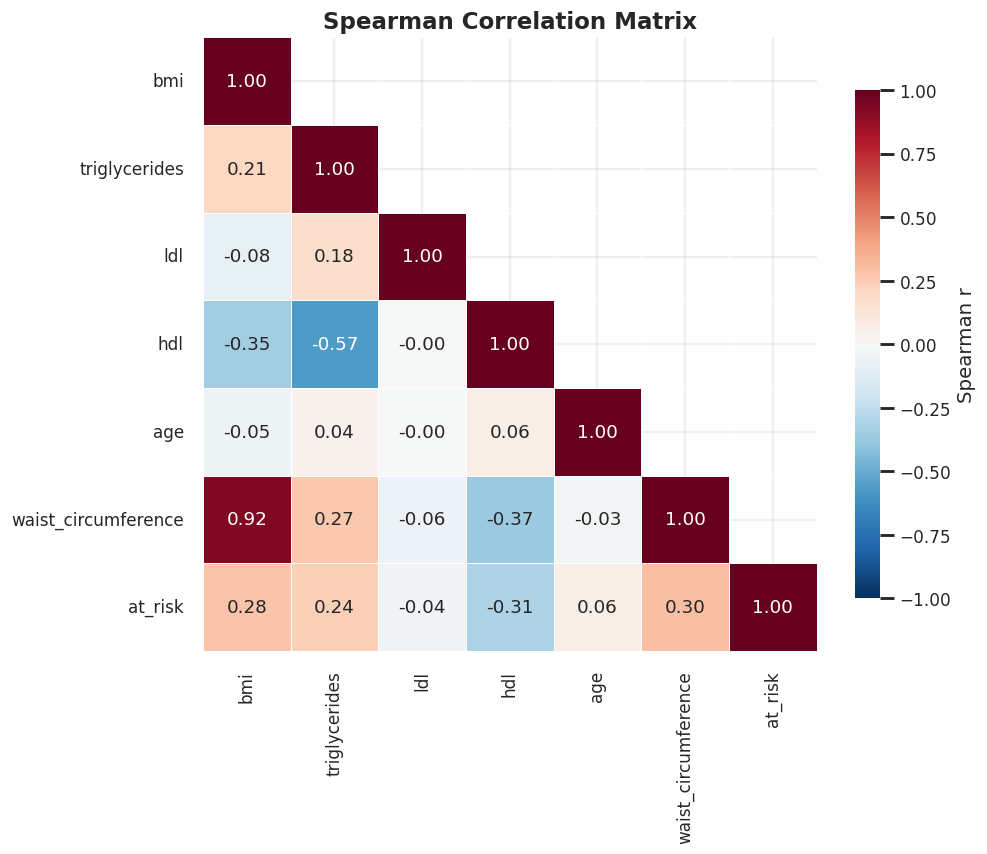

In [9]:
# ----------------------------------------------------------------------
# 4.1 / 4.2 / 4.3 Pearson & Spearman correlation heatmaps
# ----------------------------------------------------------------------
corr_feats = CONT_FEATURES + [TARGET]
pearson = df[corr_feats].corr(method="pearson")
spearman = df[corr_feats].corr(method="spearman")

for cm, name, title in [(pearson, "pearson", "Pearson"),
                        (spearman, "spearman", "Spearman")]:
    fig, ax = plt.subplots(figsize=(9, 7.5))
    mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
    sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap=CORR_CMAP,
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": f"{title} r"}, ax=ax)
    ax.set_title(f"{title} Correlation Matrix")
    save_fig(fig, f"correlation_{name}", f"{title} correlation matrix (features + target).")
    plt.show()

# Save numeric correlation tables for the thesis appendix
pearson.round(3).to_csv(TAB_DIR / "correlation_pearson.csv")
spearman.round(3).to_csv(TAB_DIR / "correlation_spearman.csv")


Top discriminative continuous features: ['hdl', 'waist_circumference', 'bmi', 'triglycerides']
  [figure saved] fig_06_pairplot_top_features.png


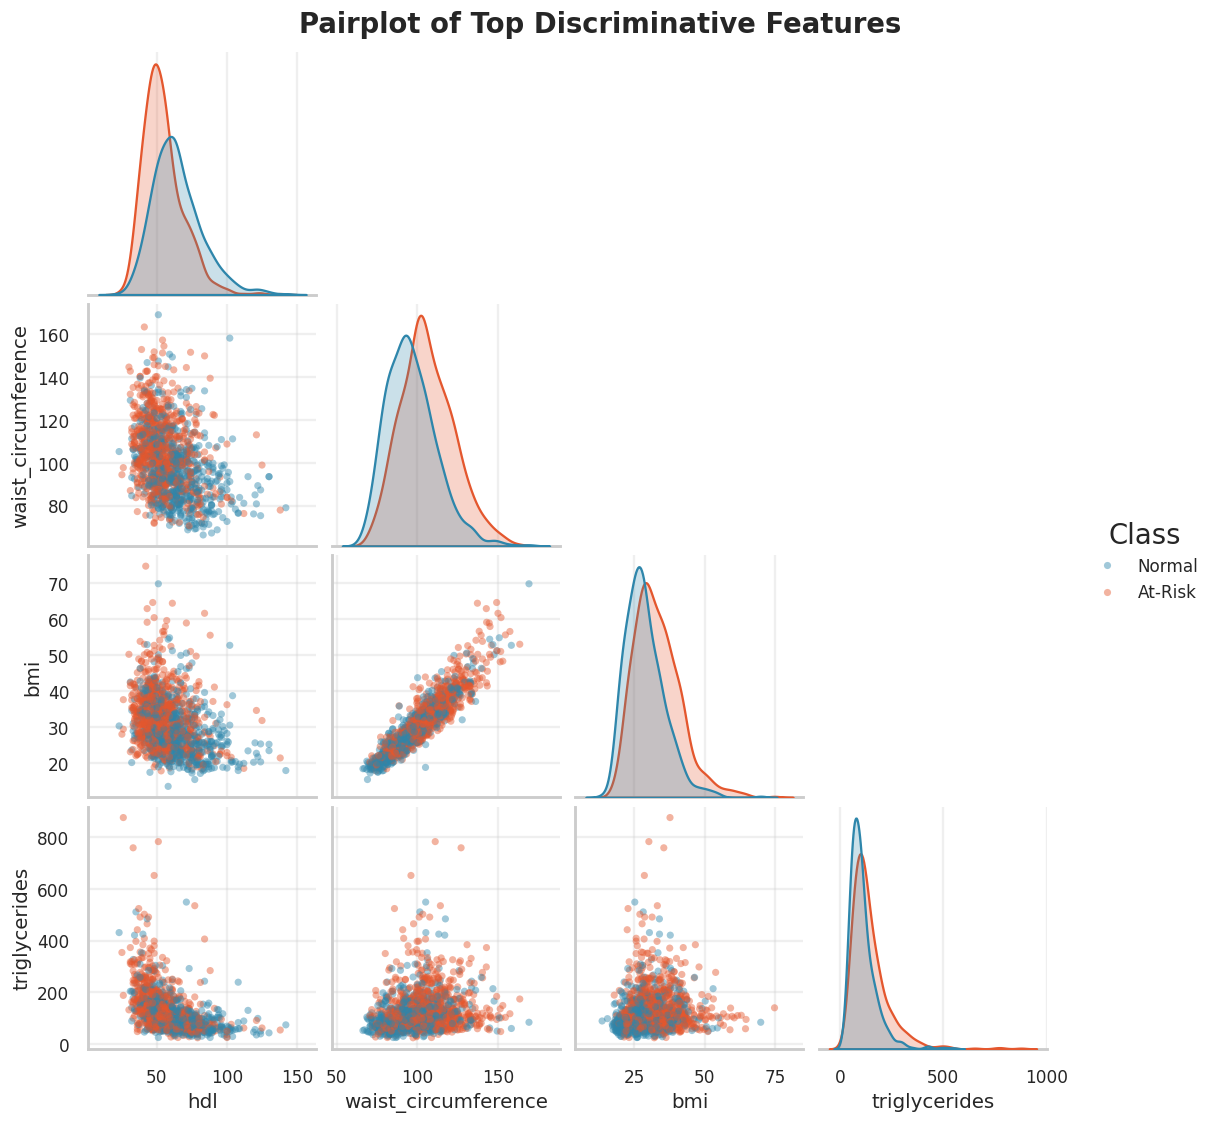

In [10]:
# ----------------------------------------------------------------------
# 4.4 Pairplot of the top discriminative continuous features
# ----------------------------------------------------------------------
# Rank continuous features by |point-biserial corr| with the target
disc = pearson[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top_feats = disc.head(4).index.tolist()
print("Top discriminative continuous features:", top_feats)

pp_df = df[top_feats + [TARGET]].copy()
pp_df["Class"] = pp_df[TARGET].map(TARGET_NAMES)
g = sns.pairplot(pp_df.drop(columns=[TARGET]), hue="Class",
                 palette=CLASS_COLORS, corner=True, diag_kind="kde",
                 plot_kws={"alpha": 0.45, "s": 22, "edgecolor": "none"})
g.fig.suptitle("Pairplot of Top Discriminative Features", y=1.02,
               fontsize=18, fontweight="bold")
save_fig(g.fig, "pairplot_top_features", "Pairwise relationships among top features by class.")
plt.show()


  [figure saved] fig_07_feature_histograms.png


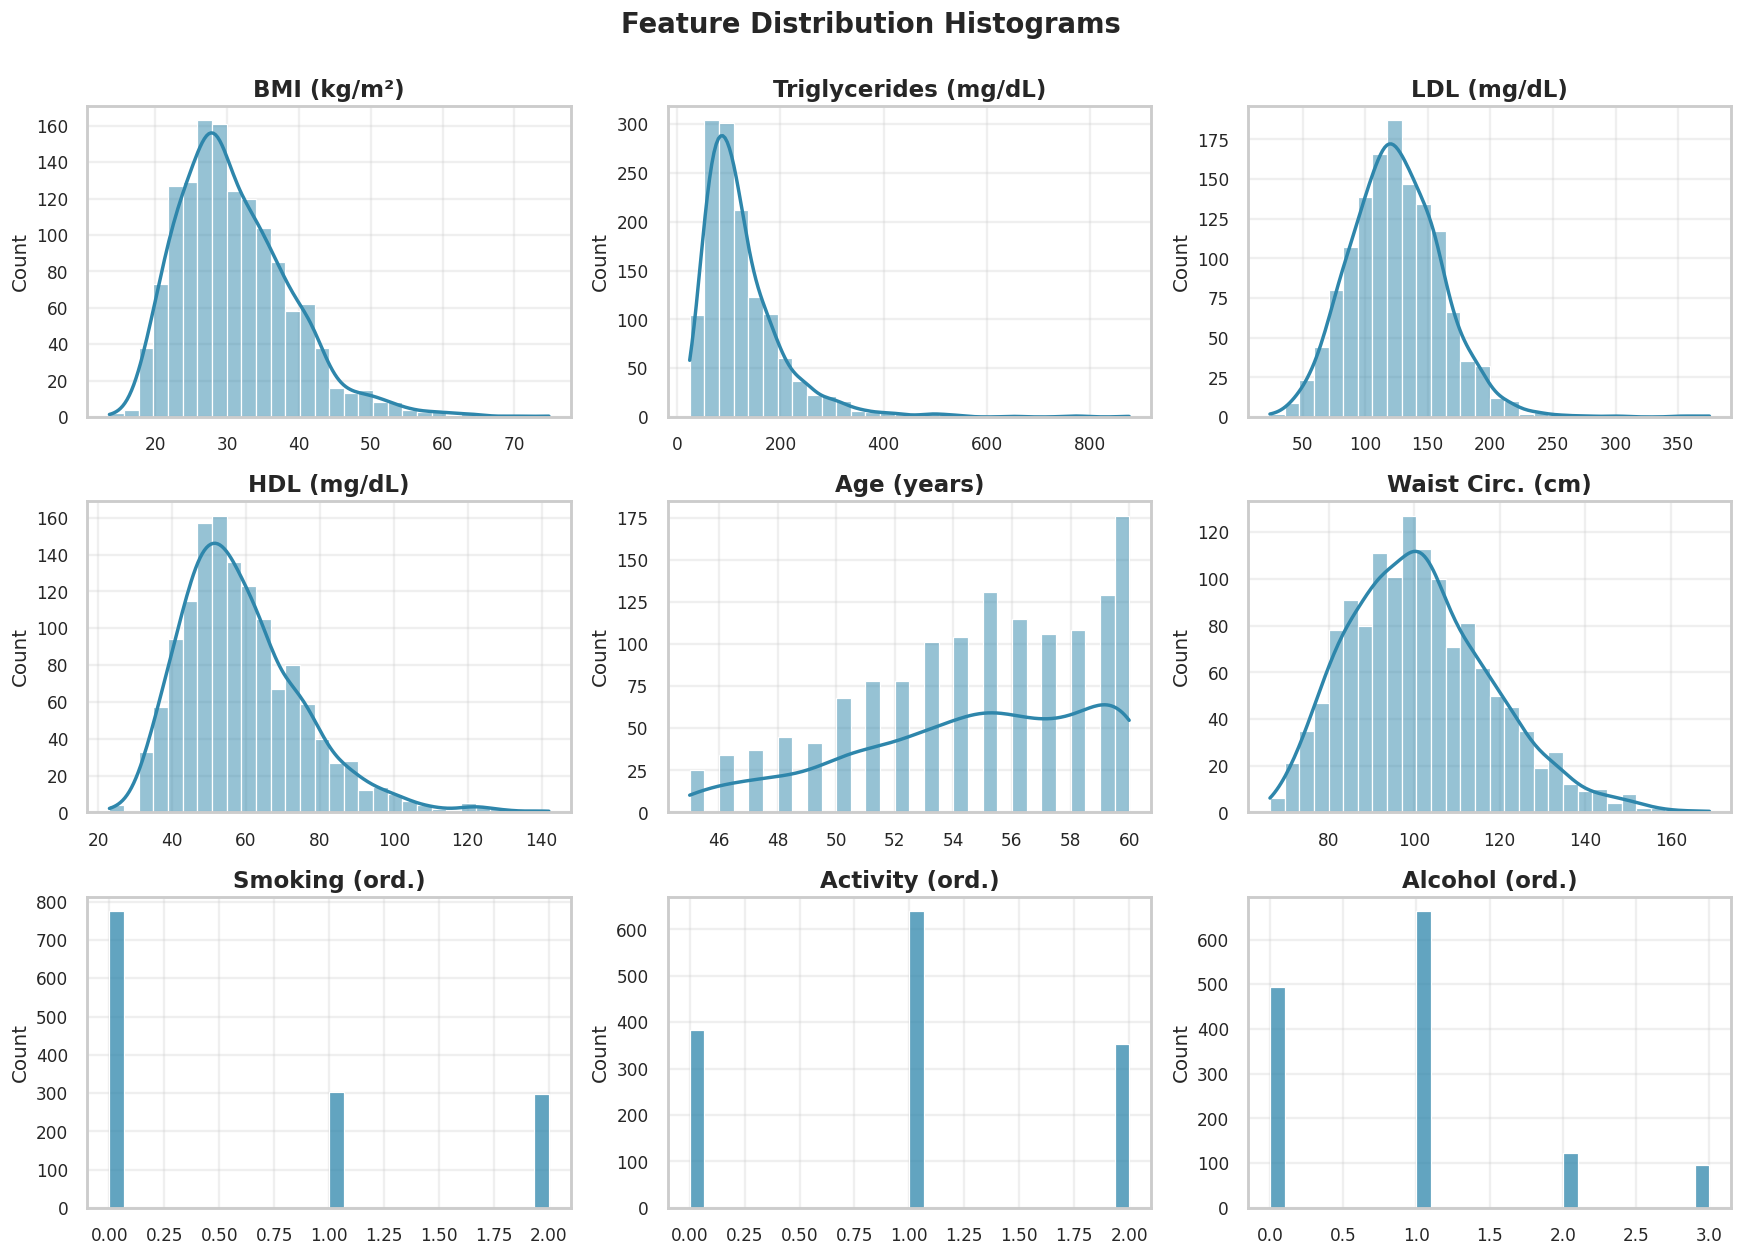

In [11]:
# ----------------------------------------------------------------------
# 4.5 Feature distribution histograms (all model features)
# ----------------------------------------------------------------------
ncols = 3
nrows = math.ceil(len(FEATURES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.8 * nrows))
axes = np.array(axes).ravel()
for i, feat in enumerate(FEATURES):
    sns.histplot(df[feat], bins=30, kde=feat in CONT_FEATURES,
                 color="#2E86AB", ax=axes[i], edgecolor="white")
    axes[i].set_title(PRETTY.get(feat, feat))
    axes[i].set_xlabel("")
for j in range(len(FEATURES), len(axes)):
    axes[j].axis("off")
fig.suptitle("Feature Distribution Histograms", fontsize=18, fontweight="bold", y=1.0)
fig.tight_layout()
save_fig(fig, "feature_histograms", "Histograms of all nine model features.")
plt.show()


  [figure saved] fig_08_boxplots_outliers.png


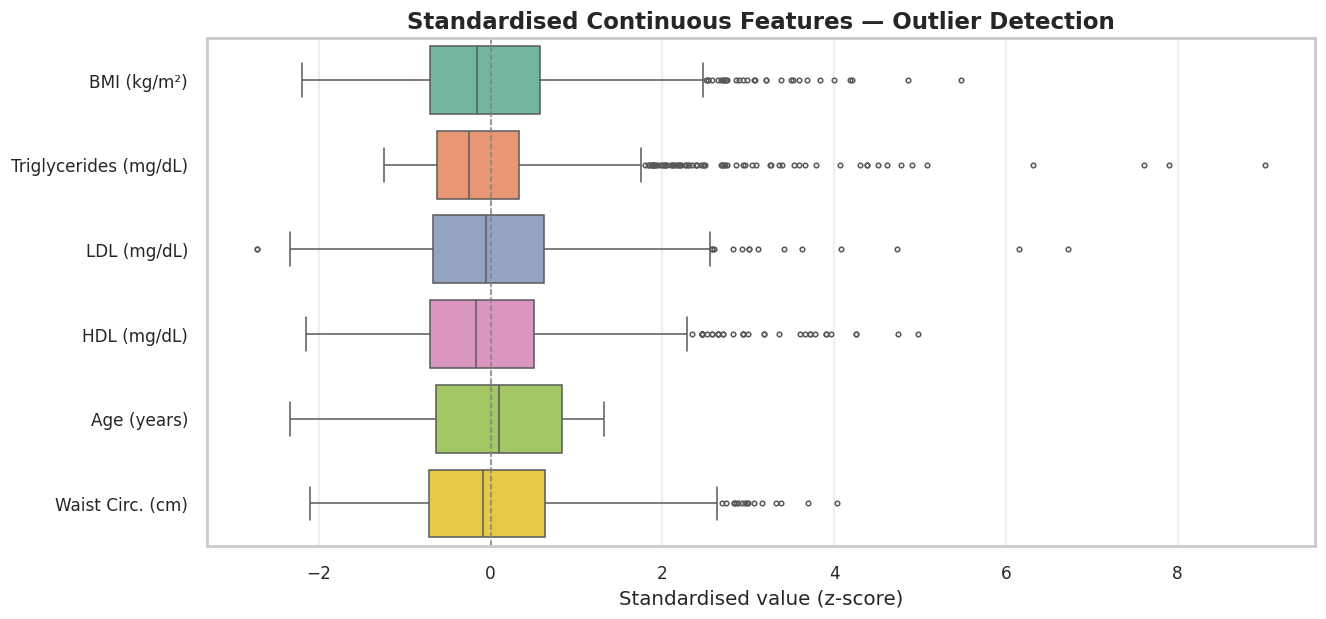

In [12]:
# ----------------------------------------------------------------------
# 4.6 Boxplots for outlier detection (standardised continuous features)
# ----------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
z = pd.DataFrame(StandardScaler().fit_transform(df[CONT_FEATURES]),
                 columns=[PRETTY.get(c, c) for c in CONT_FEATURES])
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=z, orient="h", palette="Set2", ax=ax, fliersize=3)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_title("Standardised Continuous Features — Outlier Detection")
ax.set_xlabel("Standardised value (z-score)")
save_fig(fig, "boxplots_outliers", "Standardised boxplots highlighting outliers.")
plt.show()


## 5. Feature Selection — Information Gain Analysis

We quantify each feature's **information gain** (mutual information with the target,
`mutual_info_classif`). This mirrors the project's mutual-information feature analysis. Figures:
information-gain ranking, top-10 importance, feature-retention view, and a before/after comparison.

> The production `binary_v2_no_bp` contract intentionally retains all 9 non-circular features; this
> section provides the *evidence* for that decision and flags any low-information candidates.


In [13]:
from sklearn.feature_selection import mutual_info_classif

X_all = df[FEATURES].copy()
y_all = df[TARGET].copy()

# Median-impute for the IG computation only (does not affect modelling pipeline)
X_ig = X_all.fillna(X_all.median())
discrete_mask = [f in ORD_FEATURES for f in FEATURES]

ig = mutual_info_classif(X_ig, y_all, discrete_features=discrete_mask,
                         random_state=RANDOM_STATE)
ig_df = (pd.DataFrame({"feature": FEATURES, "information_gain": ig})
         .sort_values("information_gain", ascending=False)
         .reset_index(drop=True))
ig_df["pretty"] = ig_df["feature"].map(lambda f: PRETTY.get(f, f))
print("Information Gain ranking:")
display(ig_df[["feature", "information_gain"]].round(4))

# Retention rule: keep features above a small IG floor
IG_FLOOR = 0.001
ig_df["retained"] = ig_df["information_gain"] >= IG_FLOOR
selected_features = ig_df.loc[ig_df["retained"], "feature"].tolist()
removed_features = ig_df.loc[~ig_df["retained"], "feature"].tolist()
print(f"\nSelected ({len(selected_features)}): {selected_features}")
print(f"Removed  ({len(removed_features)}): {removed_features if removed_features else 'none'}")

ig_df.drop(columns="pretty").to_csv(TAB_DIR / "feature_selection_information_gain.csv", index=False)


Information Gain ranking:


,feature,information_gain
0,hdl,0.0662
1,waist_circumference,0.0558
2,bmi,0.0314
3,alcohol_encoded,0.0151
4,triglycerides,0.0134
5,age,0.0088
6,activity_encoded,0.0057
7,smoking_encoded,0.0029
8,ldl,0.0000



Selected (8): ['hdl', 'waist_circumference', 'bmi', 'alcohol_encoded', 'triglycerides', 'age', 'activity_encoded', 'smoking_encoded']
Removed  (1): ['ldl']


  [figure saved] fig_09_information_gain_ranking.png


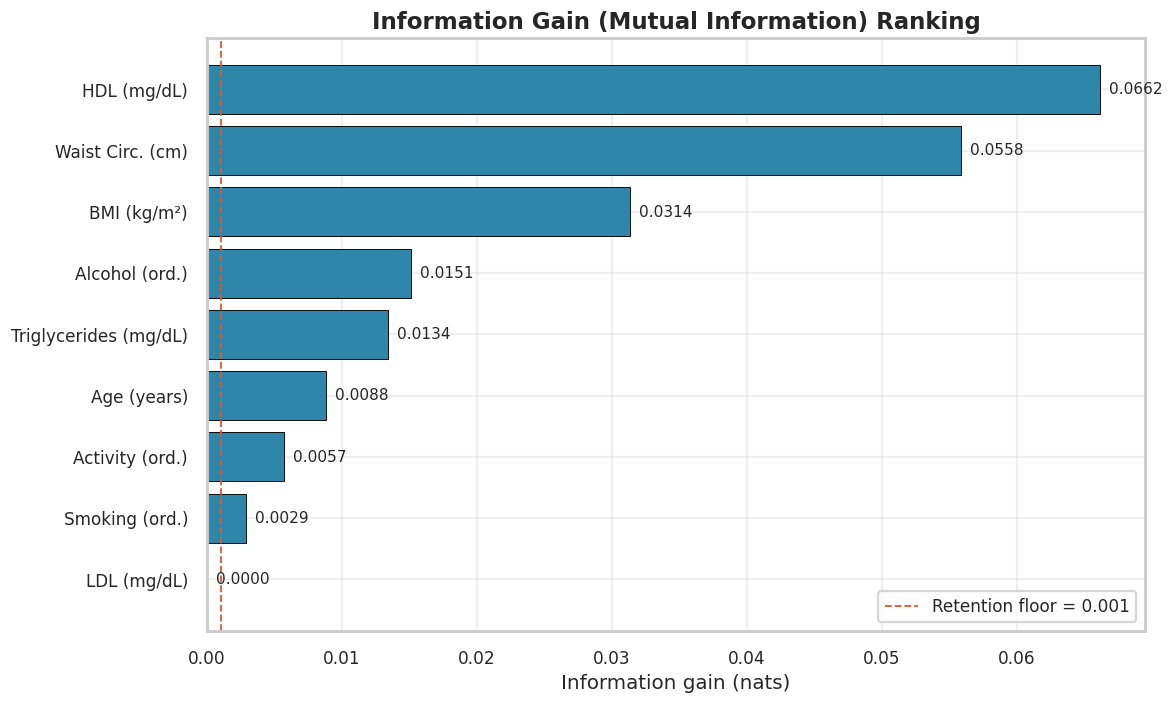

In [14]:
# ----------------------------------------------------------------------
# 5.1 Information-gain ranking bar chart
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#2E86AB" if r else "#bbbbbb" for r in ig_df["retained"]]
bars = ax.barh(ig_df["pretty"], ig_df["information_gain"], color=colors,
               edgecolor="black", linewidth=0.6)
ax.invert_yaxis()
for b, v in zip(bars, ig_df["information_gain"]):
    ax.text(v + max(ig_df["information_gain"]) * 0.01, b.get_y() + b.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=10)
ax.axvline(IG_FLOOR, color="#E4572E", ls="--", lw=1.2, label=f"Retention floor = {IG_FLOOR}")
ax.set_title("Information Gain (Mutual Information) Ranking")
ax.set_xlabel("Information gain (nats)")
ax.legend()
save_fig(fig, "information_gain_ranking", "Information-gain ranking of all features.")
plt.show()


  [figure saved] fig_10_top10_feature_importance.png


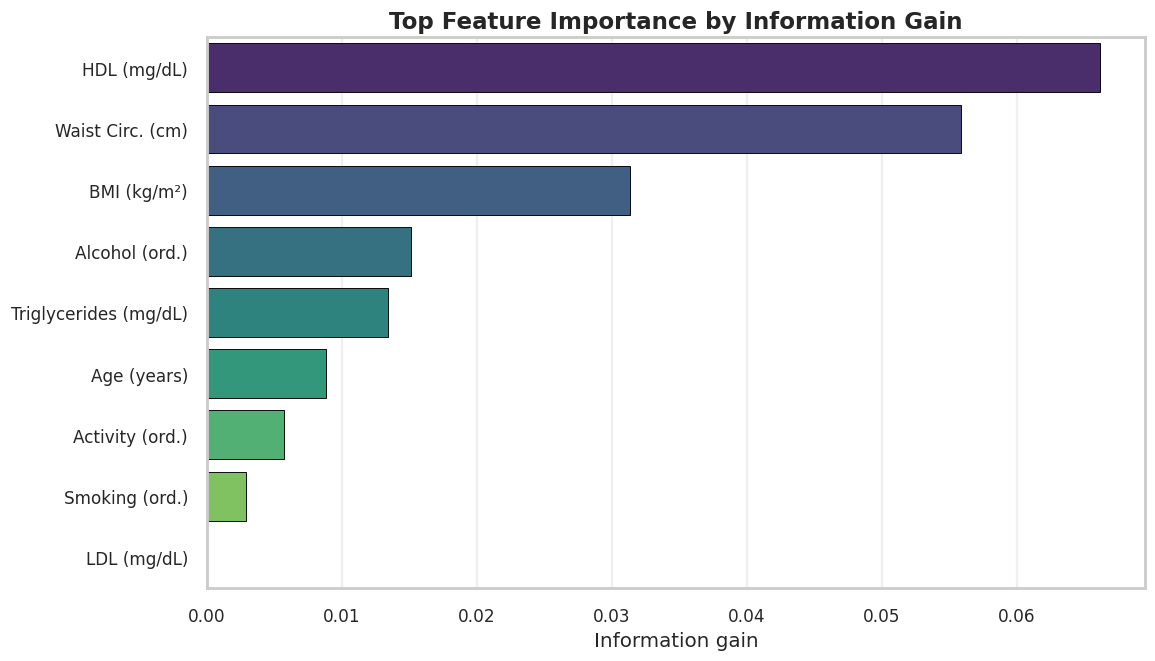

In [15]:
# ----------------------------------------------------------------------
# 5.2 Top-10 feature importance (here all 9, ranked)
# ----------------------------------------------------------------------
top10 = ig_df.head(10)
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(data=top10, y="pretty", x="information_gain",
            palette="viridis", ax=ax, edgecolor="black", linewidth=0.6)
ax.set_title("Top Feature Importance by Information Gain")
ax.set_xlabel("Information gain")
ax.set_ylabel("")
save_fig(fig, "top10_feature_importance", "Top features ranked by information gain.")
plt.show()


  [figure saved] fig_11_feature_retention.png


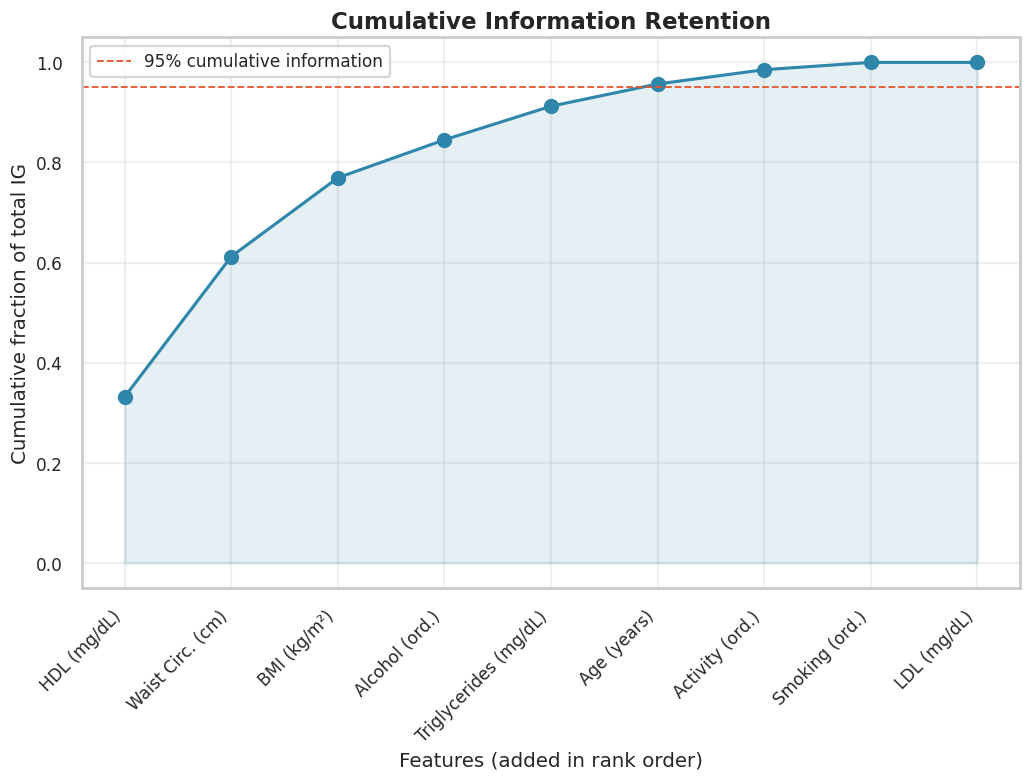

In [16]:
# ----------------------------------------------------------------------
# 5.3 Feature-retention visualisation (cumulative information)
# ----------------------------------------------------------------------
cum = ig_df["information_gain"].cumsum() / ig_df["information_gain"].sum()
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(range(1, len(cum) + 1), cum.values, marker="o", color="#2E86AB", lw=2)
ax.axhline(0.95, color="#E4572E", ls="--", lw=1.2, label="95% cumulative information")
ax.fill_between(range(1, len(cum) + 1), cum.values, alpha=0.12, color="#2E86AB")
ax.set_xticks(range(1, len(cum) + 1))
ax.set_xticklabels(ig_df["pretty"], rotation=45, ha="right")
ax.set_title("Cumulative Information Retention")
ax.set_ylabel("Cumulative fraction of total IG")
ax.set_xlabel("Features (added in rank order)")
ax.legend()
save_fig(fig, "feature_retention", "Cumulative information retained as features are added.")
plt.show()


  [figure saved] fig_12_feature_selection_before_after.png


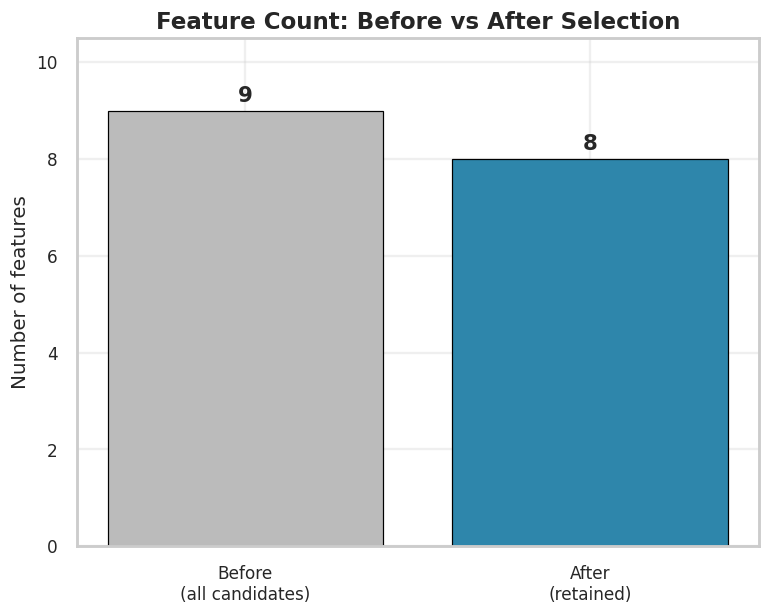

Final modelling feature set: ['hdl', 'waist_circumference', 'bmi', 'alcohol_encoded', 'triglycerides', 'age', 'activity_encoded', 'smoking_encoded']


In [17]:
# ----------------------------------------------------------------------
# 5.4 Before vs After feature selection comparison
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
comp = pd.DataFrame({
    "Stage": ["Before\n(all candidates)", "After\n(retained)"],
    "n_features": [len(FEATURES), len(selected_features)],
})
bars = ax.bar(comp["Stage"], comp["n_features"],
              color=["#bbbbbb", "#2E86AB"], edgecolor="black", linewidth=0.8)
for b, v in zip(bars, comp["n_features"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.1, str(int(v)),
            ha="center", va="bottom", fontweight="bold", fontsize=14)
ax.set_title("Feature Count: Before vs After Selection")
ax.set_ylabel("Number of features")
ax.set_ylim(0, len(FEATURES) + 1.5)
save_fig(fig, "feature_selection_before_after", "Feature count before/after IG-based retention.")
plt.show()

# Lock in the final modelling feature set
MODEL_FEATURES = selected_features if selected_features else FEATURES
print("Final modelling feature set:", MODEL_FEATURES)


## 6. Data Preparation & Model Training

**Preprocessing (leakage-safe, inside the pipeline):** continuous features → median imputation +
`StandardScaler`; ordinal encoded features → median imputation only. Imputation/scaling are fit on
training folds only.

**Validation design.** The production model uses *nested Leave-One-Group-Out* (group = NHANES
cycle). For a runnable notebook we use a **group-aware holdout**: the latest NHANES cycle is held
out for evaluation while all earlier cycles train the models. This preserves the no-wave-leakage
principle. We additionally compute **GroupKFold learning curves**.


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Keep canonical order; intersect with retained features
cont_in = [f for f in CONT_FEATURES if f in MODEL_FEATURES]
ord_in  = [f for f in ORD_FEATURES if f in MODEL_FEATURES]
MODEL_FEATURES_ORDERED = cont_in + ord_in

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cont", Pipeline([("imp", SimpleImputer(strategy="median")),
                               ("sc", StandardScaler())]), cont_in),
            ("ord",  SimpleImputer(strategy="median"), ord_in),
        ],
        remainder="drop",
    )

# ----------------------------------------------------------------------
# Group-aware holdout: latest cycle = test
# ----------------------------------------------------------------------
cycles_sorted = sorted(df[GROUP_COL].unique())
HOLDOUT_CYCLE = cycles_sorted[-1]
train_mask = df[GROUP_COL] != HOLDOUT_CYCLE
test_mask = ~train_mask

X = df[MODEL_FEATURES_ORDERED]
y = df[TARGET]
groups = df[GROUP_COL]

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train = groups[train_mask]

print(f"Holdout cycle (test): {HOLDOUT_CYCLE}")
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Train class balance: {dict(y_train.value_counts())}")
print(f"Test  class balance: {dict(y_test.value_counts())}")


Holdout cycle (test): 2021-2023
Train: 1111 rows  |  Test: 265 rows
Train class balance: {1: 616, 0: 495}
Test  class balance: {0: 147, 1: 118}


In [19]:
# ----------------------------------------------------------------------
# Candidate classifiers (optional libs included when available)
# ----------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

model_zoo = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                           random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced",
                     random_state=RANDOM_STATE),
}
if HAS_XGB:
    from xgboost import XGBClassifier
    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model_zoo["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, eval_metric="logloss", scale_pos_weight=spw,
        random_state=RANDOM_STATE, n_jobs=-1, use_label_encoder=False)
if HAS_LGBM:
    from lightgbm import LGBMClassifier
    model_zoo["LightGBM"] = LGBMClassifier(
        n_estimators=300, max_depth=-1, learning_rate=0.05, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

print(f"{len(model_zoo)} candidate models: {list(model_zoo.keys())}")


8 candidate models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Decision Tree', 'KNN', 'SVM (RBF)', 'XGBoost', 'LightGBM']


In [20]:
# ----------------------------------------------------------------------
# Train all models; collect holdout predictions & probabilities
# ----------------------------------------------------------------------
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, mean_absolute_error,
                             mean_squared_error)

fitted = {}        # name -> fitted pipeline
proba = {}         # name -> P(at-risk) on test
preds_default = {} # name -> 0/1 at 0.5

rows = []
for name, clf in model_zoo.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    if hasattr(pipe, "predict_proba"):
        p_test = pipe.predict_proba(X_test)[:, 1]
        p_train = pipe.predict_proba(X_train)[:, 1]
    else:  # fallback via decision_function -> sigmoid-ish rank
        from scipy.special import expit
        p_test = expit(pipe.decision_function(X_test))
        p_train = expit(pipe.decision_function(X_train))
    proba[name] = p_test
    yhat = (p_test >= 0.5).astype(int)
    preds_default[name] = yhat

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, yhat),
        "Precision": precision_score(y_test, yhat, zero_division=0),
        "Recall": recall_score(y_test, yhat, zero_division=0),
        "F1": f1_score(y_test, yhat, zero_division=0),
        "AUC": roc_auc_score(y_test, p_test),
        # probability-error metrics (calibration-style adaptation of MAE/RMSE)
        "MAE_train": mean_absolute_error(y_train, p_train),
        "MAE_test": mean_absolute_error(y_test, p_test),
        "RMSE_test": math.sqrt(mean_squared_error(y_test, p_test)),
    })

leaderboard = (pd.DataFrame(rows)
               .sort_values("AUC", ascending=False)
               .reset_index(drop=True))
leaderboard.insert(0, "Rank", leaderboard.index + 1)
print("MODEL LEADERBOARD (ranked by holdout AUC):")
display(leaderboard.round(4))

BEST_MODEL = leaderboard.iloc[0]["Model"]
print(f"\nBest model: {BEST_MODEL}")
leaderboard.round(4).to_csv(TAB_DIR / "model_comparison.csv", index=False)


MODEL LEADERBOARD (ranked by holdout AUC):


,Rank,Model,Accuracy,Precision,Recall,F1,AUC,MAE_train,MAE_test,RMSE_test
0,1,Logistic Regression,0.6906,0.6406,0.6949,0.6667,0.7312,0.4141,0.4196,0.4597
1,2,SVM (RBF),0.7057,0.6299,0.8220,0.7132,0.7222,0.4080,0.4315,0.4655
2,3,Gradient Boosting,0.6566,0.5828,0.8051,0.6762,0.7161,0.3333,0.4221,0.4744
3,4,Random Forest,0.6491,0.5786,0.7797,0.6643,0.6983,0.1551,0.4315,0.4788
4,5,XGBoost,0.6528,0.5956,0.6864,0.6378,0.6949,0.2766,0.4158,0.4789
5,6,KNN,0.6377,0.5688,0.7712,0.6547,0.6883,0.3929,0.4377,0.4870
6,7,Decision Tree,0.6453,0.5759,0.7712,0.6594,0.6857,0.3648,0.4259,0.4912
7,8,LightGBM,0.6340,0.5778,0.6610,0.6166,0.6577,0.1129,0.4125,0.5190



Best model: Logistic Regression


  [figure saved] fig_13_learning_curve_logistic_regression.png


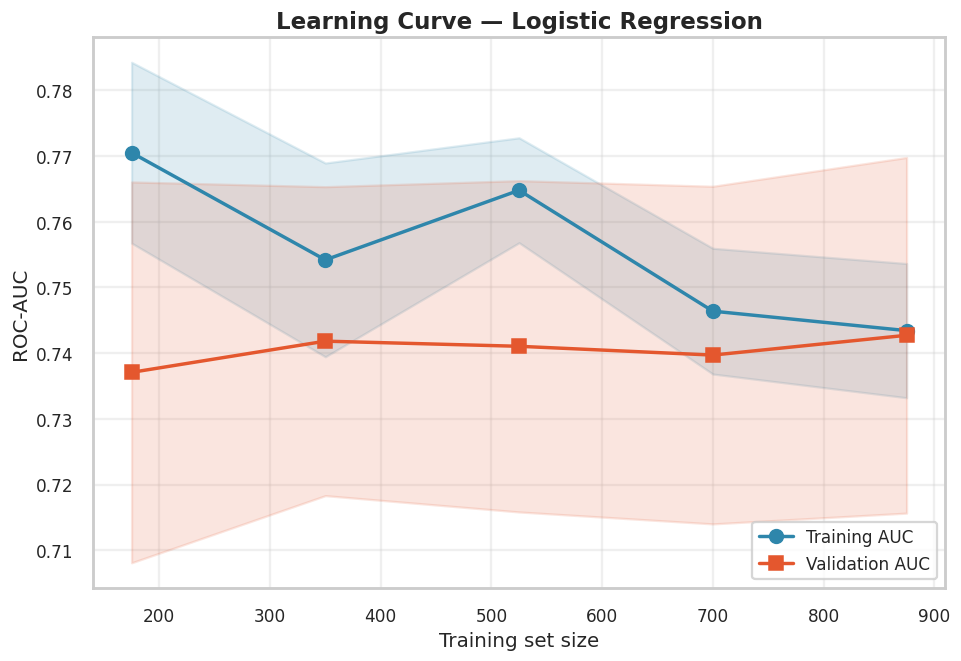

  [figure saved] fig_14_learning_curve_random_forest.png


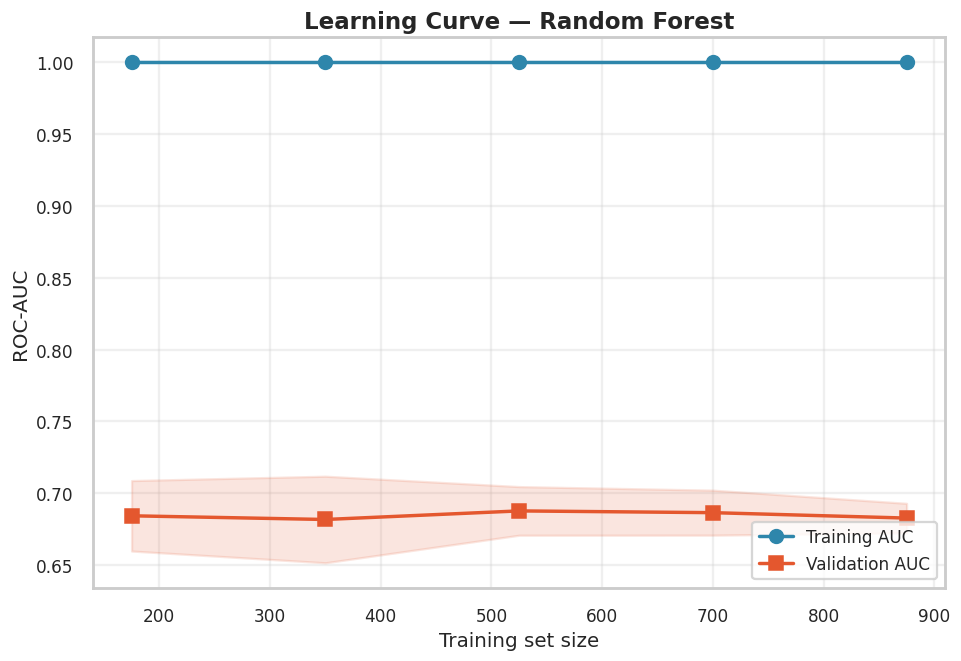

In [21]:
# ----------------------------------------------------------------------
# 6.x Learning curves (GroupKFold) per model -> train vs validation score
# ----------------------------------------------------------------------
from sklearn.model_selection import learning_curve, GroupKFold

n_groups_train = groups_train.nunique()
cv_splits = min(4, max(2, n_groups_train))
gkf = GroupKFold(n_splits=cv_splits)

curve_models = [BEST_MODEL] + [m for m in ["Random Forest", "Logistic Regression"]
                               if m != BEST_MODEL][:1]
curve_models = list(dict.fromkeys(curve_models))  # unique, keep order

for name in curve_models:
    pipe = Pipeline([("prep", make_preprocessor()), ("clf", model_zoo[name])])
    sizes, tr_scores, va_scores = learning_curve(
        pipe, X_train, y_train, groups=groups_train, cv=gkf,
        scoring="roc_auc", train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1)
    tr_m, tr_s = tr_scores.mean(1), tr_scores.std(1)
    va_m, va_s = va_scores.mean(1), va_scores.std(1)

    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.plot(sizes, tr_m, "o-", color="#2E86AB", label="Training AUC")
    ax.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color="#2E86AB")
    ax.plot(sizes, va_m, "s-", color="#E4572E", label="Validation AUC")
    ax.fill_between(sizes, va_m - va_s, va_m + va_s, alpha=0.15, color="#E4572E")
    ax.set_title(f"Learning Curve — {name}")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("ROC-AUC")
    ax.legend(loc="lower right")
    save_fig(fig, f"learning_curve_{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}",
             f"GroupKFold learning curve for {name}.")
    plt.show()


## 7. Model Evaluation

Comparison bar charts (Accuracy, AUC, F1, MAE, RMSE), a ranked leaderboard, and full
classification diagnostics for the best model: confusion matrices, ROC, precision–recall,
calibration, threshold optimisation, and prediction-error visuals.


  [figure saved] fig_15_model_comparison_accuracy.png


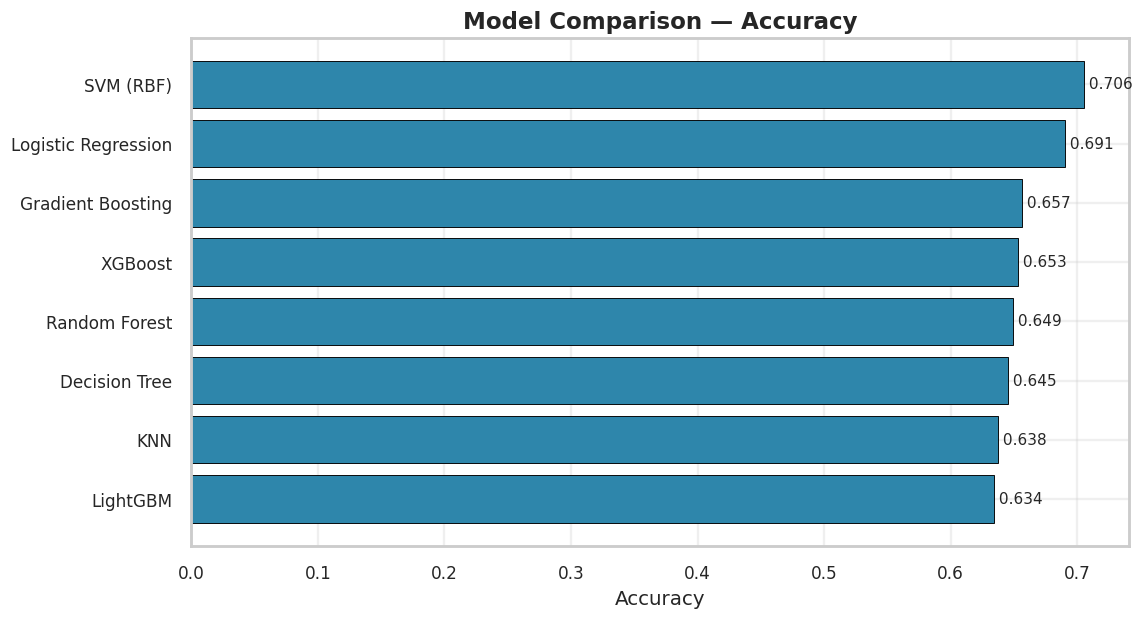

  [figure saved] fig_16_model_comparison_auc.png


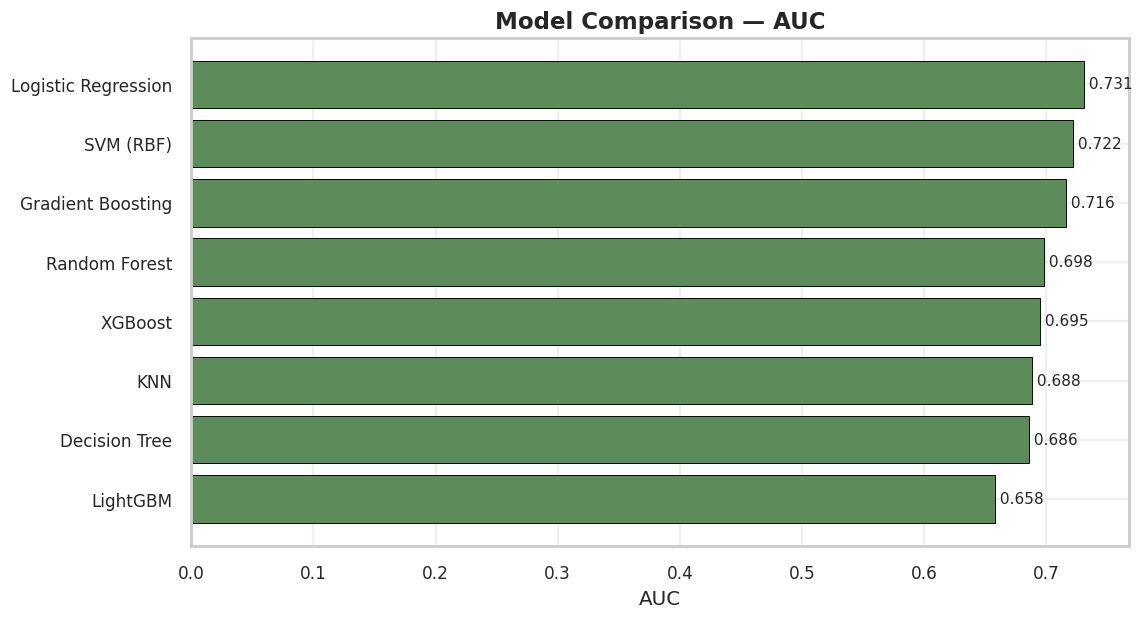

  [figure saved] fig_17_model_comparison_f1.png


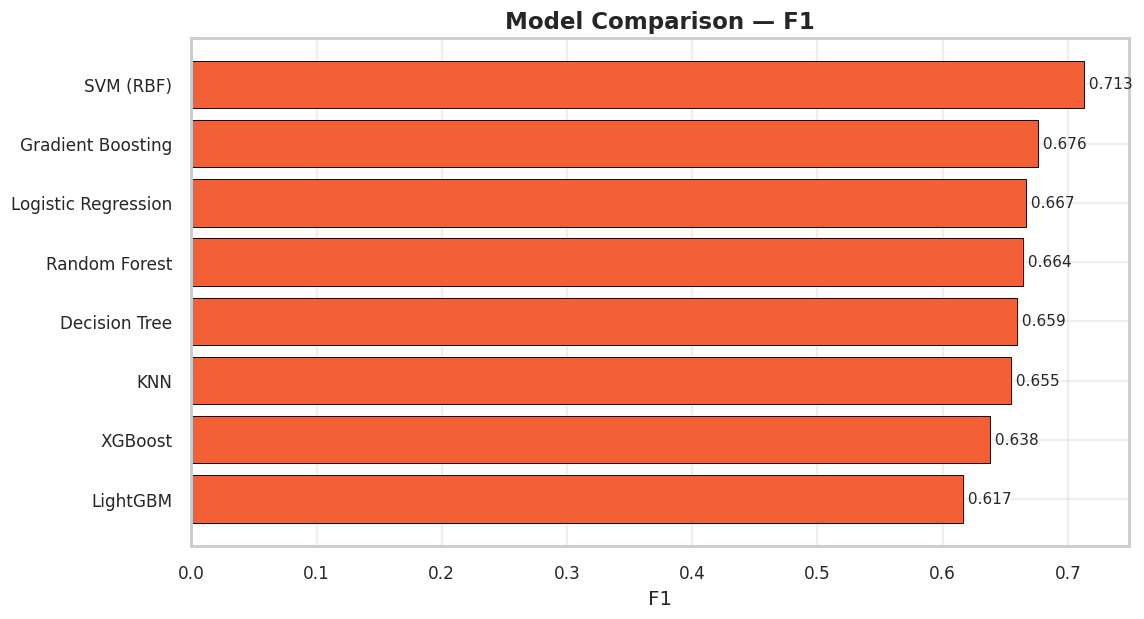

  [figure saved] fig_18_model_comparison_mae.png


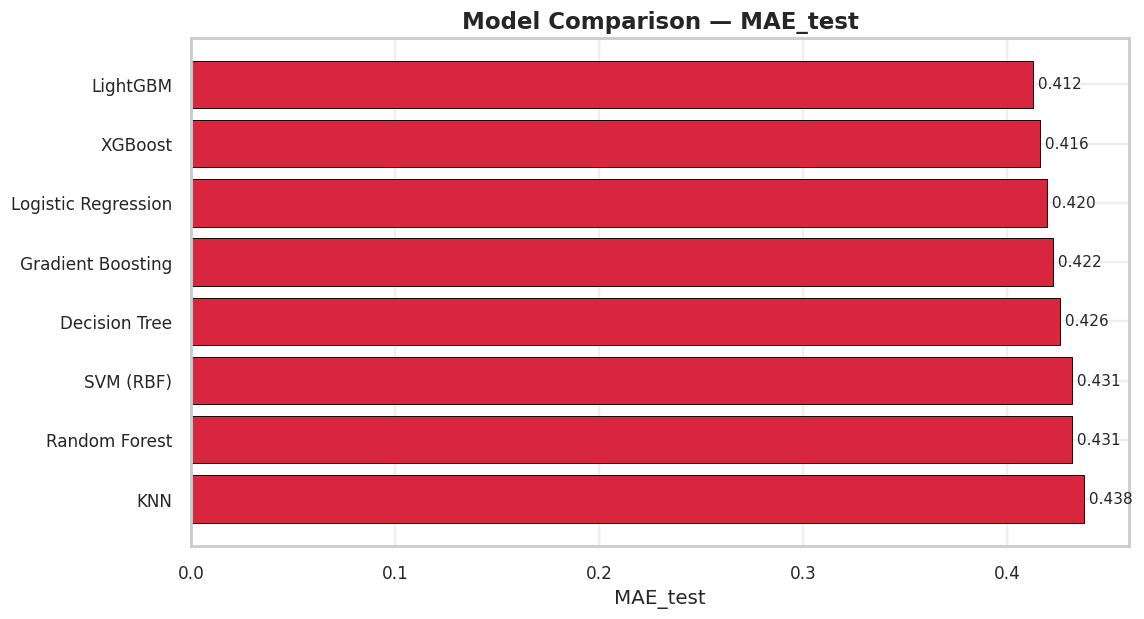

  [figure saved] fig_19_model_comparison_rmse.png


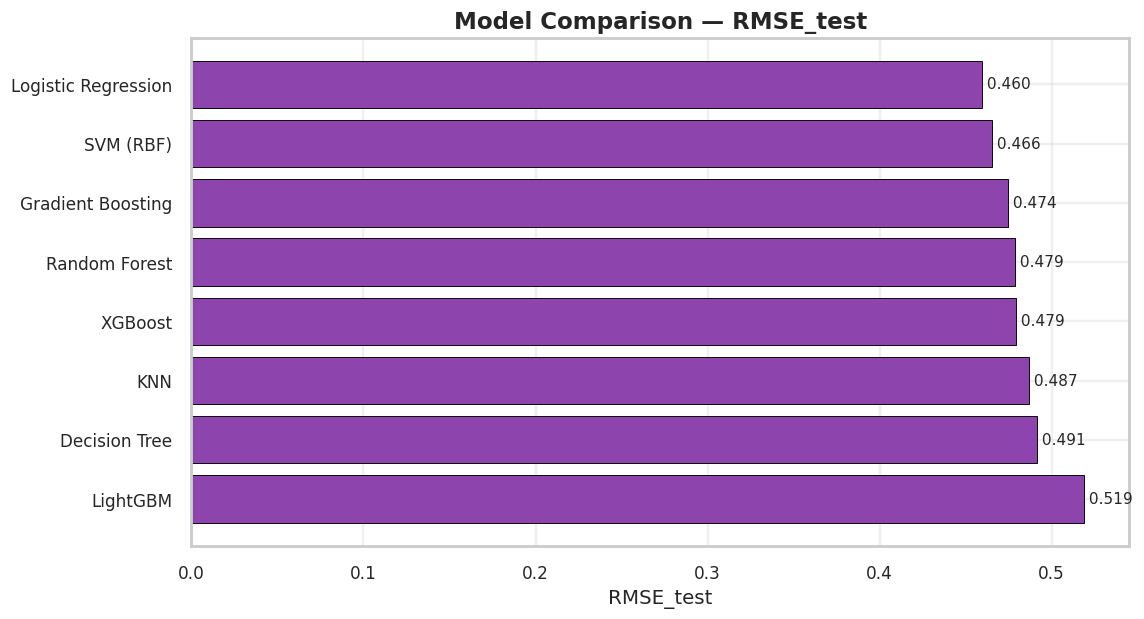

In [22]:
# ----------------------------------------------------------------------
# 7.1 Model comparison bar charts
# ----------------------------------------------------------------------
def comparison_bar(metric, higher_better=True, fname=None, color="#2E86AB"):
    d = leaderboard.sort_values(metric, ascending=not higher_better)
    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(d["Model"], d[metric], color=color, edgecolor="black", linewidth=0.6)
    ax.invert_yaxis()
    for b, v in zip(bars, d[metric]):
        ax.text(v, b.get_y() + b.get_height() / 2, f" {v:.3f}", va="center", fontsize=10)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_xlabel(metric)
    save_fig(fig, fname or f"model_comparison_{metric.lower()}", f"Cross-model {metric} comparison.")
    plt.show()

comparison_bar("Accuracy", color="#2E86AB")
comparison_bar("AUC", color="#5B8C5A")
comparison_bar("F1", color="#F46036")
comparison_bar("MAE_test", higher_better=False, fname="model_comparison_mae", color="#D7263D")
comparison_bar("RMSE_test", higher_better=False, fname="model_comparison_rmse", color="#8E44AD")


  [figure saved] fig_20_mae_train_vs_validation_bar.png


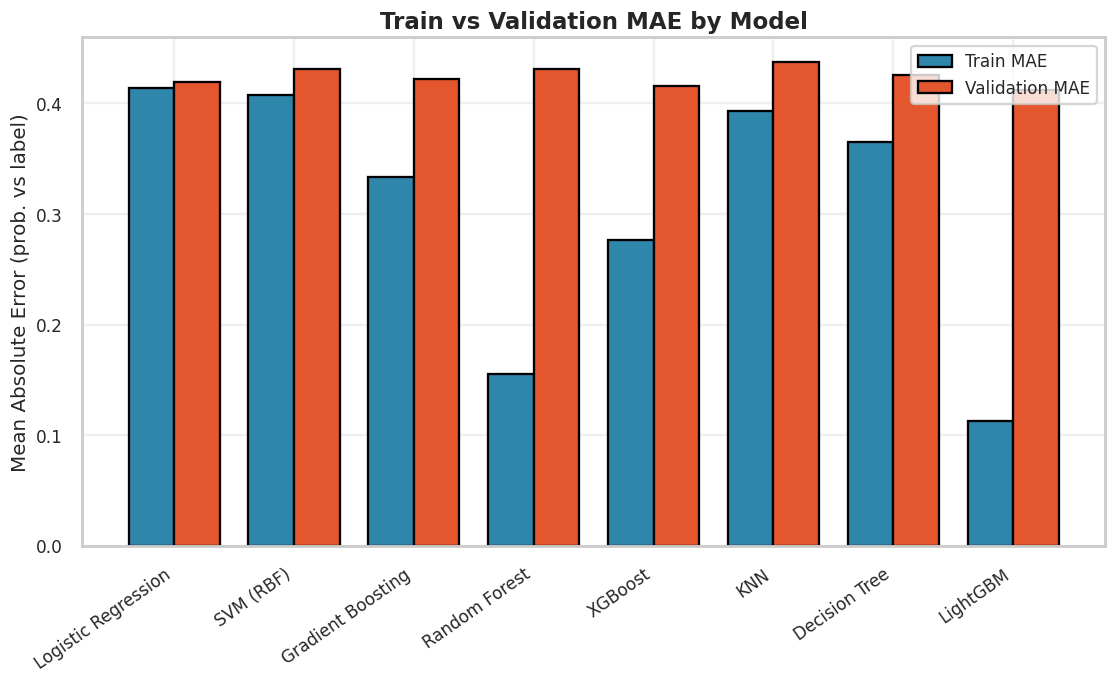

  [figure saved] fig_21_mae_train_vs_validation_line.png


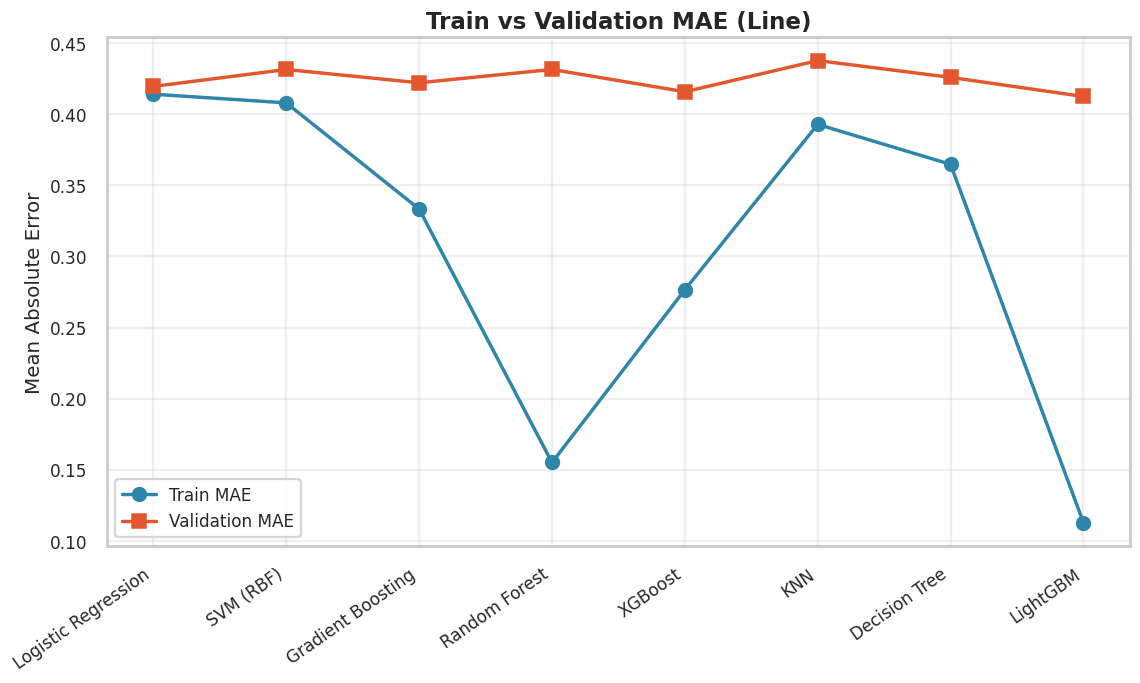

In [23]:
# ----------------------------------------------------------------------
# 7.2 MAE analysis: Train vs Validation (bar + line) and metrics dashboard
# ----------------------------------------------------------------------
# Bar: train vs test MAE per model
fig, ax = plt.subplots(figsize=(12, 6))
xpos = np.arange(len(leaderboard))
w = 0.38
ax.bar(xpos - w/2, leaderboard["MAE_train"], w, label="Train MAE", color="#2E86AB", edgecolor="black")
ax.bar(xpos + w/2, leaderboard["MAE_test"], w, label="Validation MAE", color="#E4572E", edgecolor="black")
ax.set_xticks(xpos)
ax.set_xticklabels(leaderboard["Model"], rotation=35, ha="right")
ax.set_ylabel("Mean Absolute Error (prob. vs label)")
ax.set_title("Train vs Validation MAE by Model")
ax.legend()
save_fig(fig, "mae_train_vs_validation_bar", "Train vs validation MAE per model.")
plt.show()

# Line version
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(leaderboard["Model"], leaderboard["MAE_train"], "o-", color="#2E86AB", label="Train MAE")
ax.plot(leaderboard["Model"], leaderboard["MAE_test"], "s-", color="#E4572E", label="Validation MAE")
ax.set_xticklabels(leaderboard["Model"], rotation=35, ha="right")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Train vs Validation MAE (Line)")
ax.legend()
save_fig(fig, "mae_train_vs_validation_line", "Train vs validation MAE (line).")
plt.show()


  [figure saved] fig_22_metrics_dashboard.png


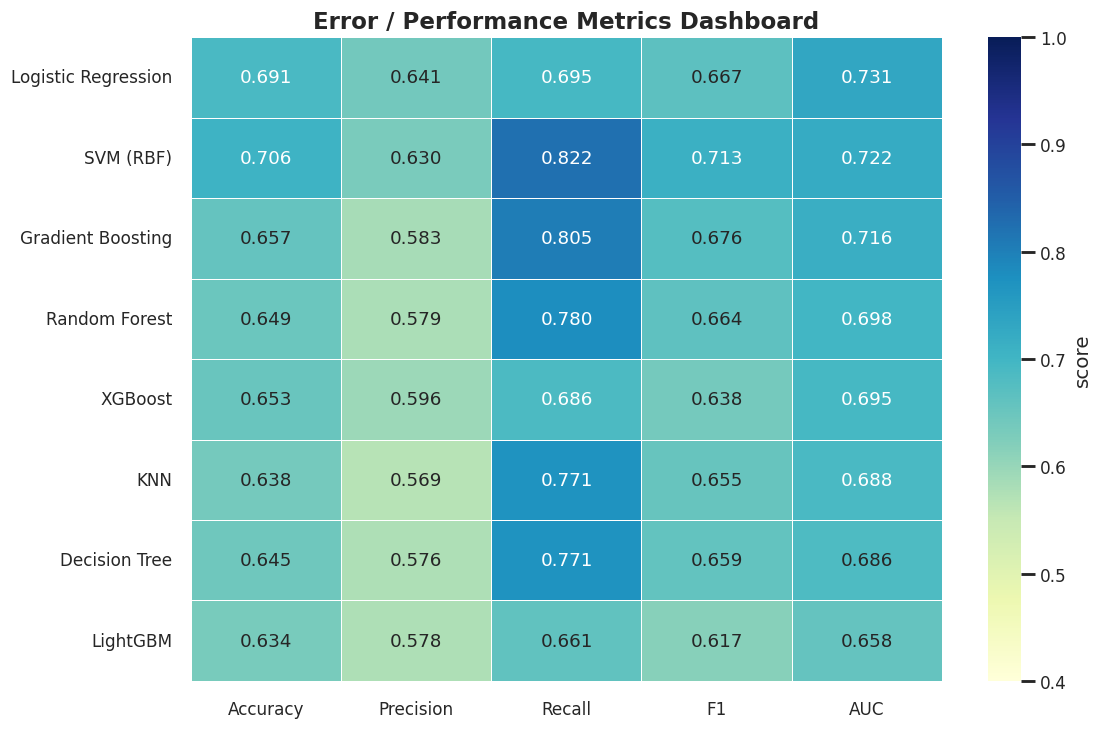

In [24]:
# ----------------------------------------------------------------------
# 7.3 Error-metrics comparison dashboard (heatmap of normalised metrics)
# ----------------------------------------------------------------------
dash_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
dash = leaderboard.set_index("Model")[dash_cols]
fig, ax = plt.subplots(figsize=(11, 0.7 * len(dash) + 2))
sns.heatmap(dash, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.4, vmax=1.0,
            linewidths=0.5, cbar_kws={"label": "score"}, ax=ax)
ax.set_title("Error / Performance Metrics Dashboard")
ax.set_ylabel("")
save_fig(fig, "metrics_dashboard", "Per-model classification metrics dashboard.")
plt.show()


In [25]:
# ----------------------------------------------------------------------
# Best-model artefacts for the remaining diagnostics
# ----------------------------------------------------------------------
best_pipe = fitted[BEST_MODEL]
best_proba = proba[BEST_MODEL]

# Project's tuned operating threshold (Youden-based) for the screening model
PROJECT_THRESHOLD = 0.465
best_pred = (best_proba >= PROJECT_THRESHOLD).astype(int)
print(f"Best model: {BEST_MODEL}  |  operating threshold = {PROJECT_THRESHOLD}")


Best model: Logistic Regression  |  operating threshold = 0.465


  [figure saved] fig_23_confusion_matrix_counts.png


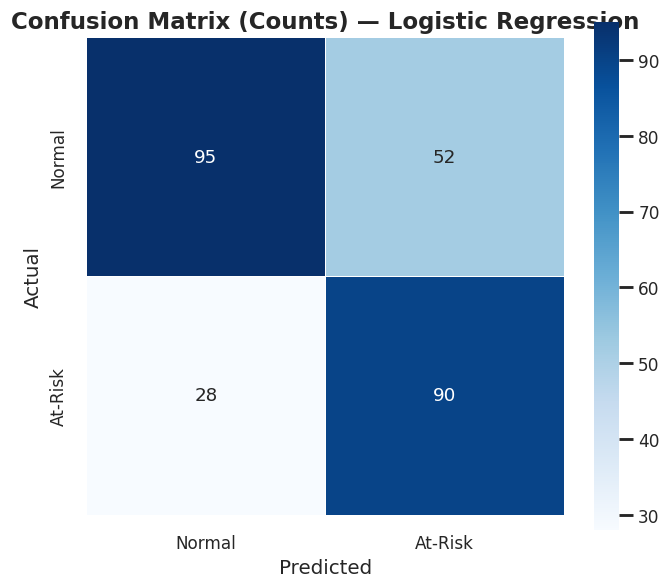

  [figure saved] fig_24_confusion_matrix_normalized.png


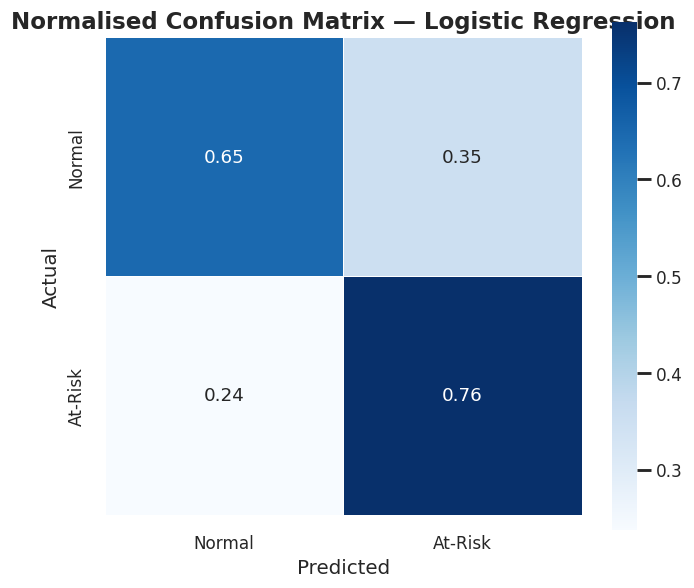

              precision    recall  f1-score   support

      Normal       0.77      0.65      0.70       147
     At-Risk       0.63      0.76      0.69       118

    accuracy                           0.70       265
   macro avg       0.70      0.70      0.70       265
weighted avg       0.71      0.70      0.70       265



In [26]:
# ----------------------------------------------------------------------
# 7.4 Confusion matrix (counts) and normalised confusion matrix
# ----------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, best_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels = [TARGET_NAMES[0], TARGET_NAMES[1]]

for matrix, fmt, tag, title in [(cm, "d", "counts", "Confusion Matrix (Counts)"),
                                (cm_norm, ".2f", "normalized", "Normalised Confusion Matrix")]:
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap="Blues", cbar=True,
                xticklabels=labels, yticklabels=labels, square=True,
                linewidths=0.5, ax=ax)
    ax.set_title(f"{title} — {BEST_MODEL}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    save_fig(fig, f"confusion_matrix_{tag}", f"{title} for the best model.")
    plt.show()

print(classification_report(y_test, best_pred, target_names=labels))


  [figure saved] fig_25_roc_curves.png


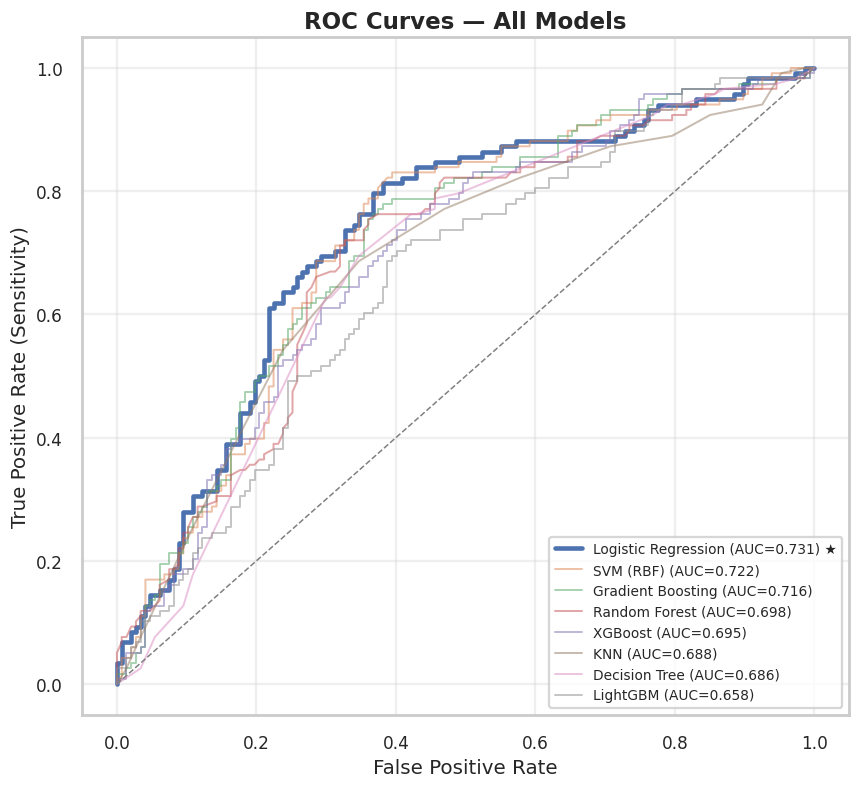

In [27]:
# ----------------------------------------------------------------------
# 7.5 ROC curve (with AUC) for all models, best highlighted
# ----------------------------------------------------------------------
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 8))
for name in leaderboard["Model"]:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    a = auc(fpr, tpr)
    lw, alpha = (3, 1.0) if name == BEST_MODEL else (1.3, 0.5)
    ax.plot(fpr, tpr, lw=lw, alpha=alpha,
            label=f"{name} (AUC={a:.3f})" + (" \u2605" if name == BEST_MODEL else ""))
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax.set_title("ROC Curves — All Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.legend(loc="lower right", fontsize=9)
save_fig(fig, "roc_curves", "ROC curves for all models.")
plt.show()


  [figure saved] fig_26_precision_recall_curve.png


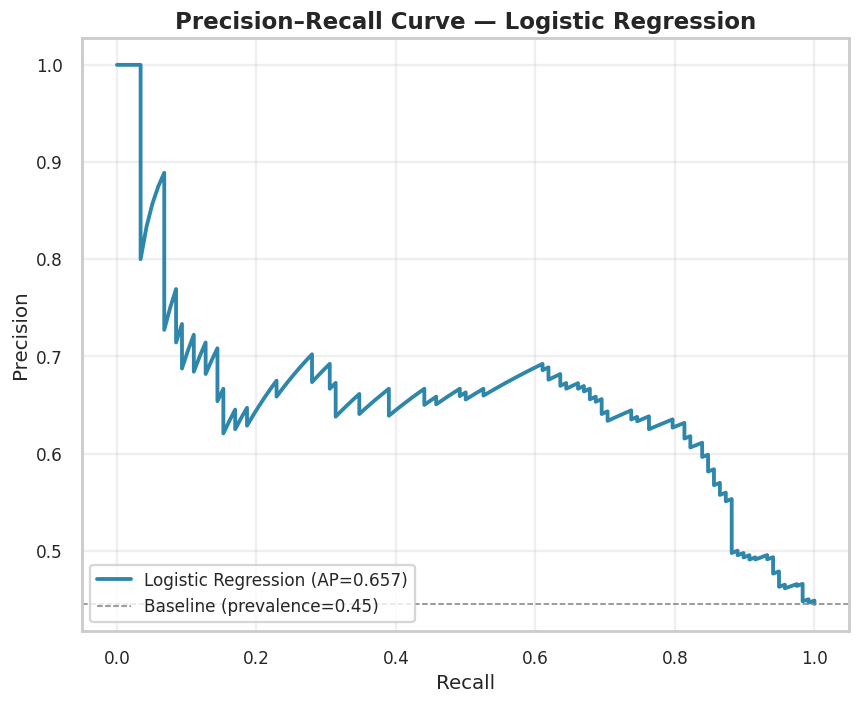

In [28]:
# ----------------------------------------------------------------------
# 7.6 Precision-Recall curve (best model)
# ----------------------------------------------------------------------
prec, rec, _ = precision_recall_curve(y_test, best_proba)
ap = average_precision_score(y_test, best_proba)
baseline = y_test.mean()
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(rec, prec, color="#2E86AB", lw=2.5, label=f"{BEST_MODEL} (AP={ap:.3f})")
ax.axhline(baseline, ls="--", color="grey", lw=1, label=f"Baseline (prevalence={baseline:.2f})")
ax.set_title(f"Precision–Recall Curve — {BEST_MODEL}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
save_fig(fig, "precision_recall_curve", "Precision-recall curve for the best model.")
plt.show()


  [figure saved] fig_27_calibration_curve.png


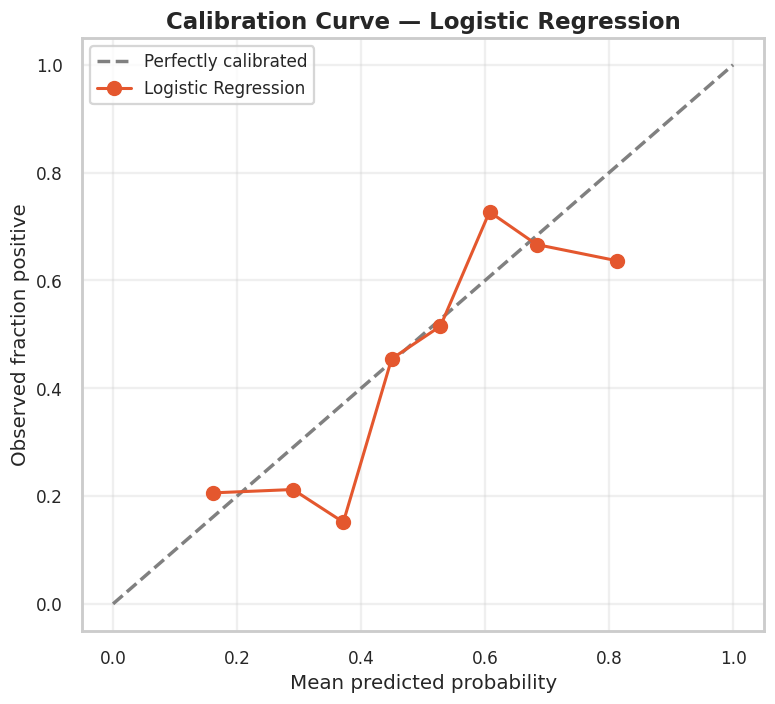

In [29]:
# ----------------------------------------------------------------------
# 7.7 Calibration curve (reliability diagram)
# ----------------------------------------------------------------------
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfectly calibrated")
ax.plot(mean_pred, frac_pos, "o-", color="#E4572E", lw=2, label=BEST_MODEL)
ax.set_title(f"Calibration Curve — {BEST_MODEL}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.legend(loc="upper left")
save_fig(fig, "calibration_curve", "Reliability diagram for the best model.")
plt.show()


  [figure saved] fig_28_threshold_optimization.png


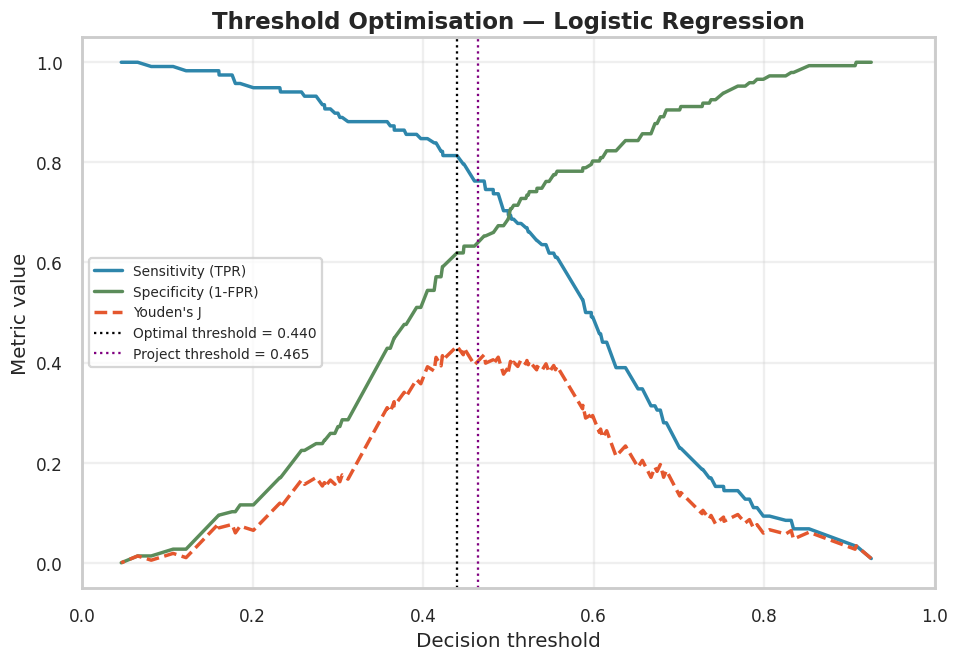

In [30]:
# ----------------------------------------------------------------------
# 7.8 Threshold optimisation (Youden's J) + sensitivity/specificity tradeoff
# ----------------------------------------------------------------------
fpr, tpr, thr = roc_curve(y_test, best_proba)
youden = tpr - fpr
best_idx = int(np.argmax(youden))
opt_thr = thr[best_idx]

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.plot(thr, tpr, color="#2E86AB", label="Sensitivity (TPR)")
ax.plot(thr, 1 - fpr, color="#5B8C5A", label="Specificity (1-FPR)")
ax.plot(thr, youden, color="#E4572E", ls="--", label="Youden's J")
ax.axvline(opt_thr, color="black", ls=":", lw=1.5,
           label=f"Optimal threshold = {opt_thr:.3f}")
ax.axvline(PROJECT_THRESHOLD, color="purple", ls=":", lw=1.5,
           label=f"Project threshold = {PROJECT_THRESHOLD}")
ax.set_xlim(0, 1)
ax.set_title(f"Threshold Optimisation — {BEST_MODEL}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.legend(loc="center left", fontsize=9)
save_fig(fig, "threshold_optimization", "Threshold sweep with Youden-optimal point.")
plt.show()


  [figure saved] fig_29_actual_vs_predicted_diagnostics.png


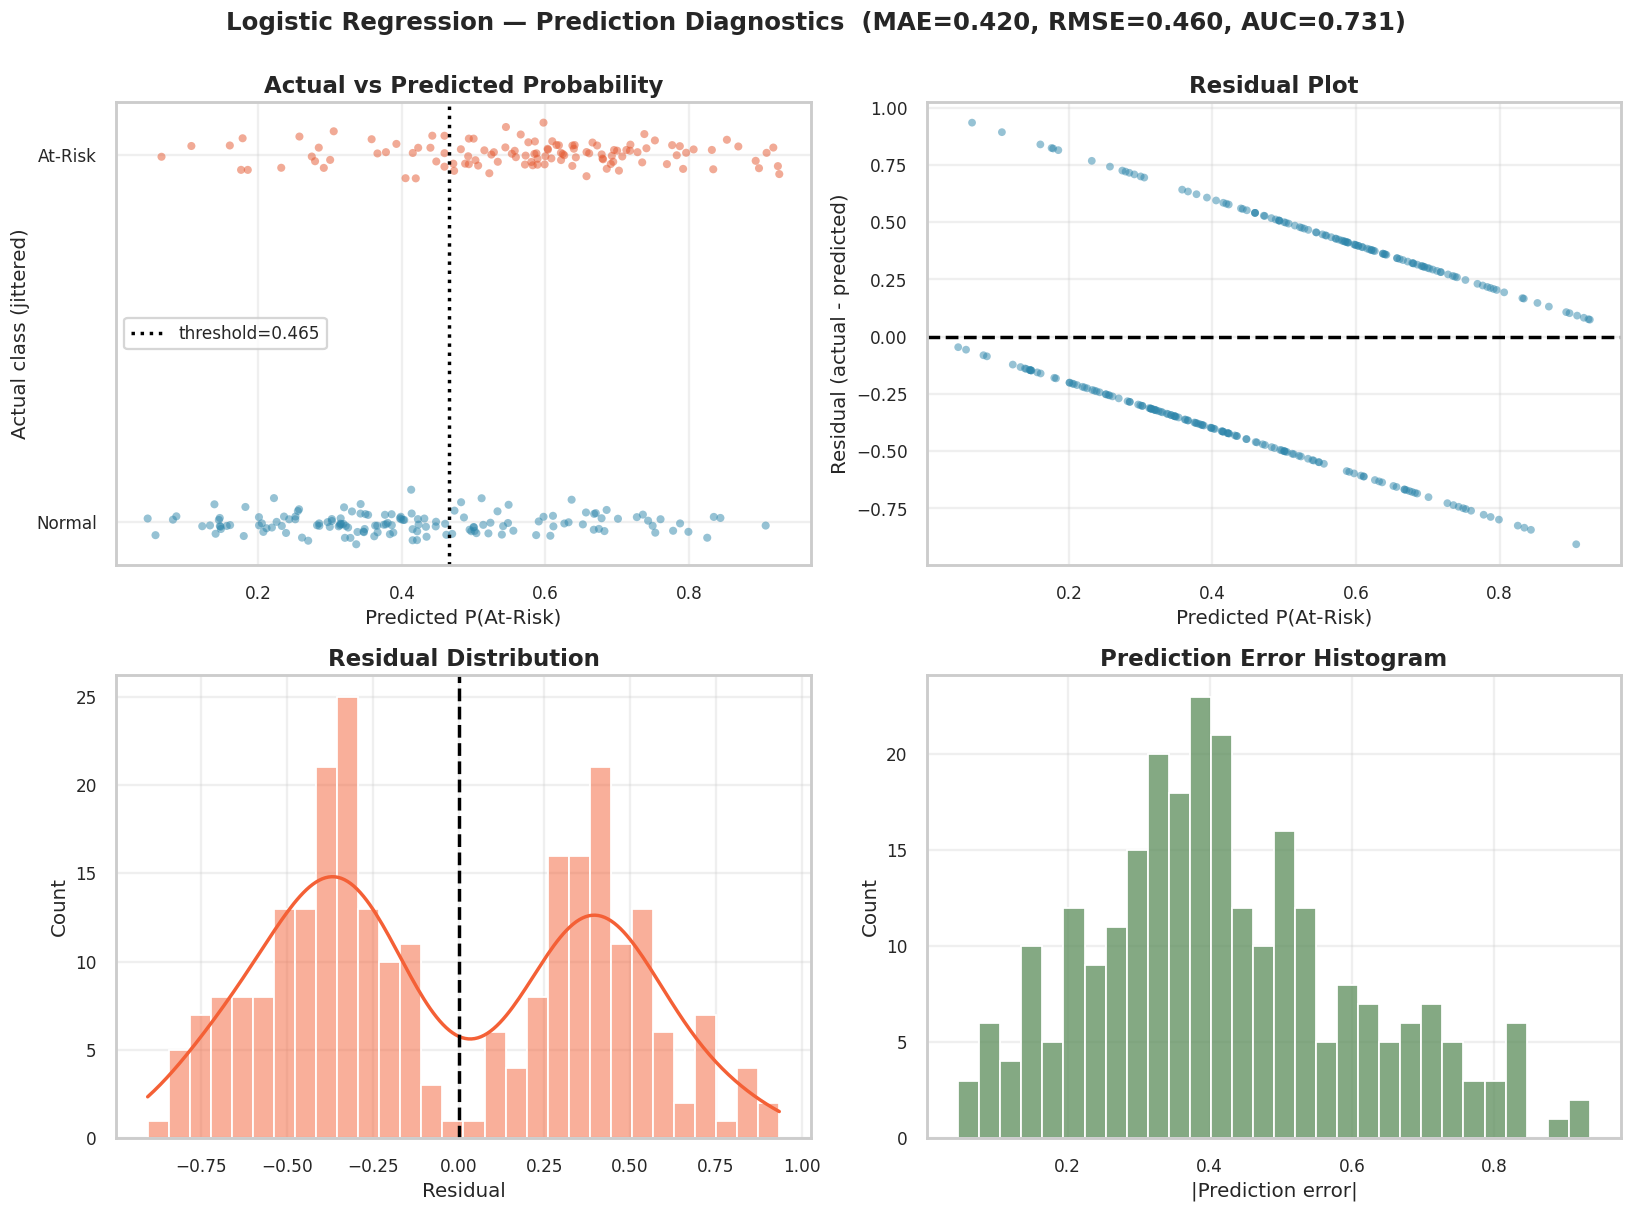

In [31]:
# ----------------------------------------------------------------------
# 7.9 Actual vs Predicted (probability) + residual diagnostics
#     For a classifier we treat the predicted P(at-risk) as the prediction
#     and the 0/1 label as the actual value (calibration-style view).
# ----------------------------------------------------------------------
resid = y_test.values - best_proba
rng = np.random.default_rng(RANDOM_STATE)
jitter = rng.normal(0, 0.03, size=len(y_test))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (a) Actual vs predicted scatter
ax = axes[0, 0]
ax.scatter(best_proba, y_test + jitter, c=[CLASS_COLORS[v] for v in y_test],
           alpha=0.5, s=28, edgecolor="none")
ax.axvline(PROJECT_THRESHOLD, color="black", ls=":", label=f"threshold={PROJECT_THRESHOLD}")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "At-Risk"])
ax.set_xlabel("Predicted P(At-Risk)"); ax.set_ylabel("Actual class (jittered)")
ax.set_title("Actual vs Predicted Probability")
ax.legend(loc="center left")

# (b) Residual vs predicted
ax = axes[0, 1]
ax.scatter(best_proba, resid, alpha=0.5, s=26, color="#2E86AB", edgecolor="none")
ax.axhline(0, color="black", ls="--")
ax.set_xlabel("Predicted P(At-Risk)"); ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residual Plot")

# (c) Residual distribution
ax = axes[1, 0]
sns.histplot(resid, bins=30, kde=True, color="#F46036", ax=ax, edgecolor="white")
ax.axvline(0, color="black", ls="--")
ax.set_xlabel("Residual"); ax.set_title("Residual Distribution")

# (d) Absolute prediction-error histogram
ax = axes[1, 1]
sns.histplot(np.abs(resid), bins=30, color="#5B8C5A", ax=ax, edgecolor="white")
ax.set_xlabel("|Prediction error|"); ax.set_title("Prediction Error Histogram")

mae = np.abs(resid).mean()
rmse = math.sqrt((resid ** 2).mean())
fig.suptitle(f"{BEST_MODEL} — Prediction Diagnostics  (MAE={mae:.3f}, RMSE={rmse:.3f}, "
             f"AUC={roc_auc_score(y_test, best_proba):.3f})",
             fontsize=16, fontweight="bold", y=1.0)
fig.tight_layout()
save_fig(fig, "actual_vs_predicted_diagnostics", "Actual-vs-predicted, residual and error diagnostics.")
plt.show()


  [figure saved] fig_30_lift_and_gain_curves.png


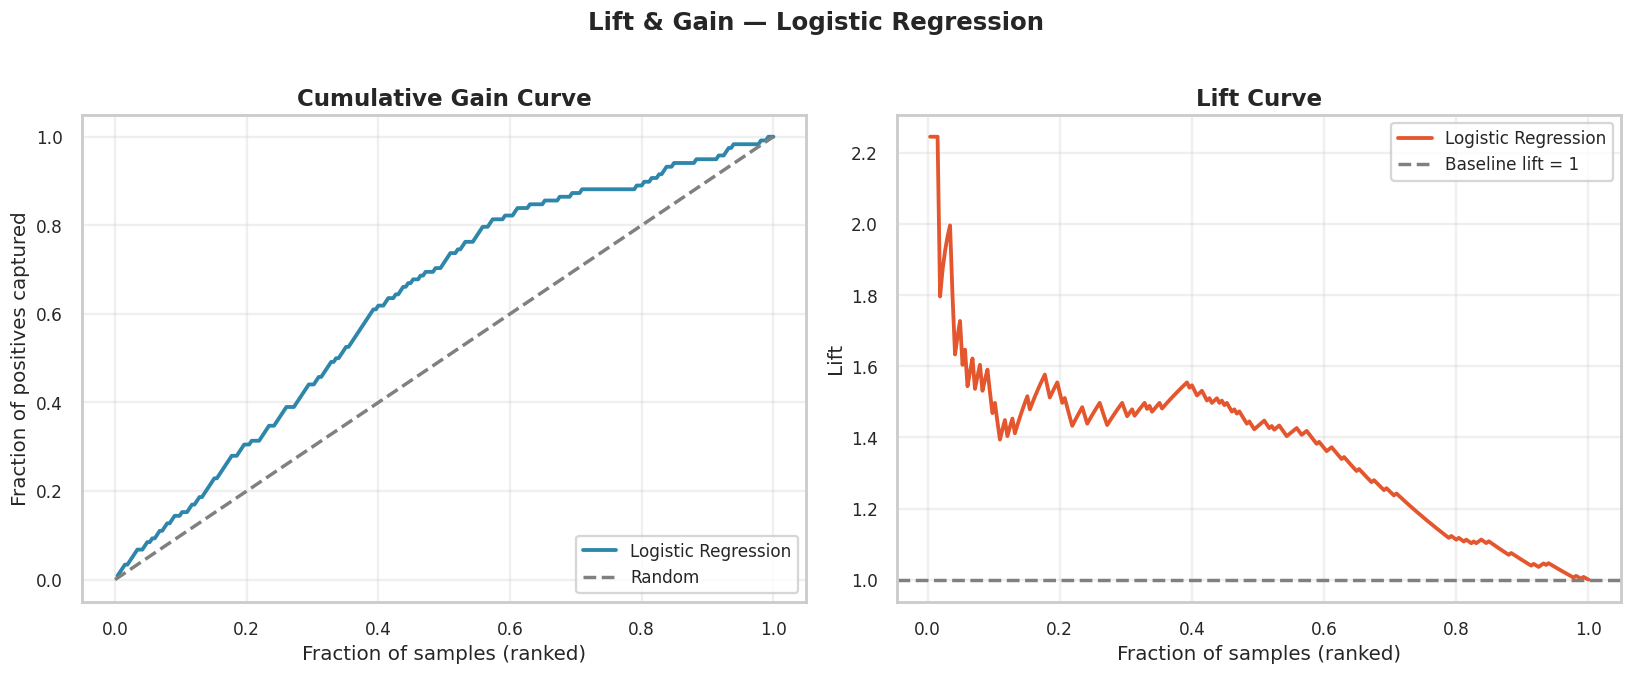

In [32]:
# ----------------------------------------------------------------------
# 7.10 Lift & Gain (cumulative) curves for the best model
# ----------------------------------------------------------------------
order = np.argsort(-best_proba)
y_sorted = y_test.values[order]
cum_pos = np.cumsum(y_sorted)
total_pos = cum_pos[-1]
pct_samples = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
gain = cum_pos / total_pos
lift = gain / pct_samples

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(pct_samples, gain, color="#2E86AB", lw=2.5, label=BEST_MODEL)
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random")
axes[0].set_title("Cumulative Gain Curve"); axes[0].set_xlabel("Fraction of samples (ranked)")
axes[0].set_ylabel("Fraction of positives captured"); axes[0].legend(loc="lower right")

axes[1].plot(pct_samples, lift, color="#E4572E", lw=2.5, label=BEST_MODEL)
axes[1].axhline(1, ls="--", color="grey", label="Baseline lift = 1")
axes[1].set_title("Lift Curve"); axes[1].set_xlabel("Fraction of samples (ranked)")
axes[1].set_ylabel("Lift"); axes[1].legend(loc="upper right")
fig.suptitle(f"Lift & Gain — {BEST_MODEL}", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "lift_and_gain_curves", "Cumulative gain and lift curves.")
plt.show()


### 7b. Model Comparison: Actual vs Predicted

Side-by-side predicted-probability distributions for every model, split by true class. A
well-separating model pushes *Normal* mass to the left and *At-Risk* mass to the right. The
best model (highest AUC) is highlighted.


  [figure saved] fig_31_model_comparison_actual_vs_predicted.png


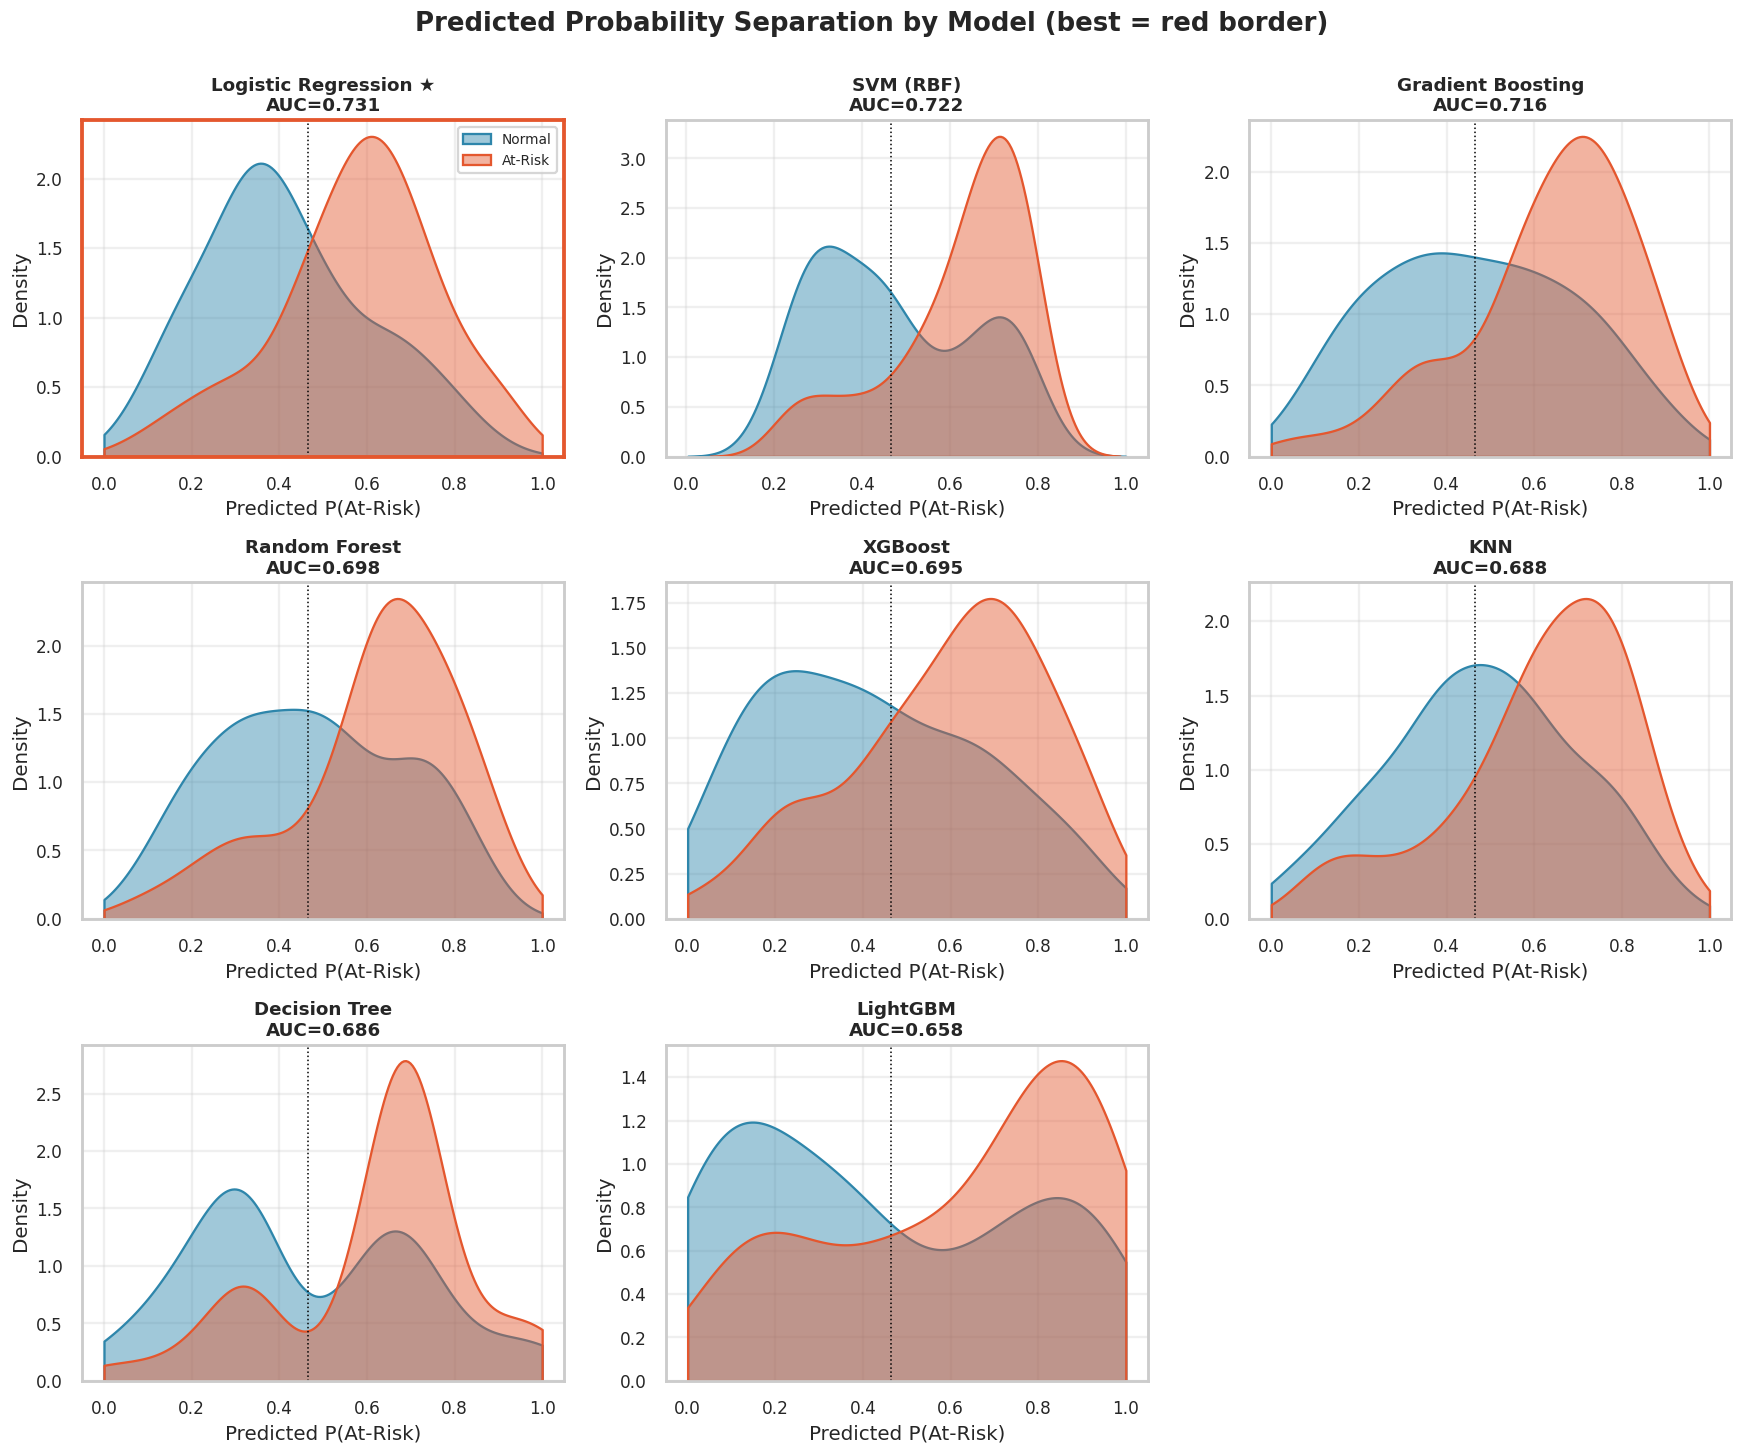

In [33]:
n = len(leaderboard)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.4 * nrows))
axes = np.array(axes).ravel()
for i, name in enumerate(leaderboard["Model"]):
    ax = axes[i]
    p = proba[name]
    for cls_val, color, lab in [(0, C_NORMAL, "Normal"), (1, C_RISK, "At-Risk")]:
        sns.kdeplot(p[y_test.values == cls_val], fill=True, alpha=0.45,
                    color=color, ax=ax, label=lab, clip=(0, 1))
    ax.axvline(PROJECT_THRESHOLD, color="black", ls=":", lw=1)
    star = " \u2605" if name == BEST_MODEL else ""
    ax.set_title(f"{name}{star}\nAUC={leaderboard.loc[leaderboard['Model']==name,'AUC'].values[0]:.3f}",
                 fontsize=12)
    ax.set_xlabel("Predicted P(At-Risk)")
    if i == 0:
        ax.legend(fontsize=9)
    else:
        leg = ax.get_legend()
        if leg: leg.remove()
    if name == BEST_MODEL:
        for spine in ax.spines.values():
            spine.set_edgecolor("#E4572E"); spine.set_linewidth(2.5)
for j in range(n, len(axes)):
    axes[j].axis("off")
fig.suptitle("Predicted Probability Separation by Model (best = red border)",
             fontsize=17, fontweight="bold", y=1.0)
fig.tight_layout()
save_fig(fig, "model_comparison_actual_vs_predicted", "Per-model predicted-probability separation.")
plt.show()


## 8. Clustering Analysis — Weighted K-Means (Ahlqvist K=4)

Following Ahlqvist et al. (2018), we cluster the **at-risk** population into **K=4** metabolic
subtypes (SIRD, SIDD, MOD, MARD) using the 6 continuous biomarkers with **expert-elicited weights**
(`bmi×1.5, triglycerides×2.0, ldl×2.5, hdl×1.2, age×1.0, waist×2.0`). Weighting is applied by
scaling standardised features by √weight before Euclidean K-Means — an equivalent weighted-distance
formulation. Figures: elbow, silhouette, PCA / t-SNE / UMAP projections, cluster distribution, and a
centroid heatmap.


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# Cluster the at-risk cohort (clinically the relevant population for subtyping)
clust_df = df[df[TARGET] == 1].copy()
Xc_raw = clust_df[CLUSTER_FEATURES].fillna(clust_df[CLUSTER_FEATURES].median())

scaler_c = StandardScaler()
Xc_std = scaler_c.fit_transform(Xc_raw)
w = np.sqrt(np.array([CLUSTER_WEIGHTS[f] for f in CLUSTER_FEATURES]))
Xc_w = Xc_std * w  # weighted feature space

print(f"Clustering {Xc_w.shape[0]} at-risk participants on {len(CLUSTER_FEATURES)} weighted features.")


Clustering 734 at-risk participants on 6 weighted features.


  [figure saved] fig_32_cluster_k_selection.png


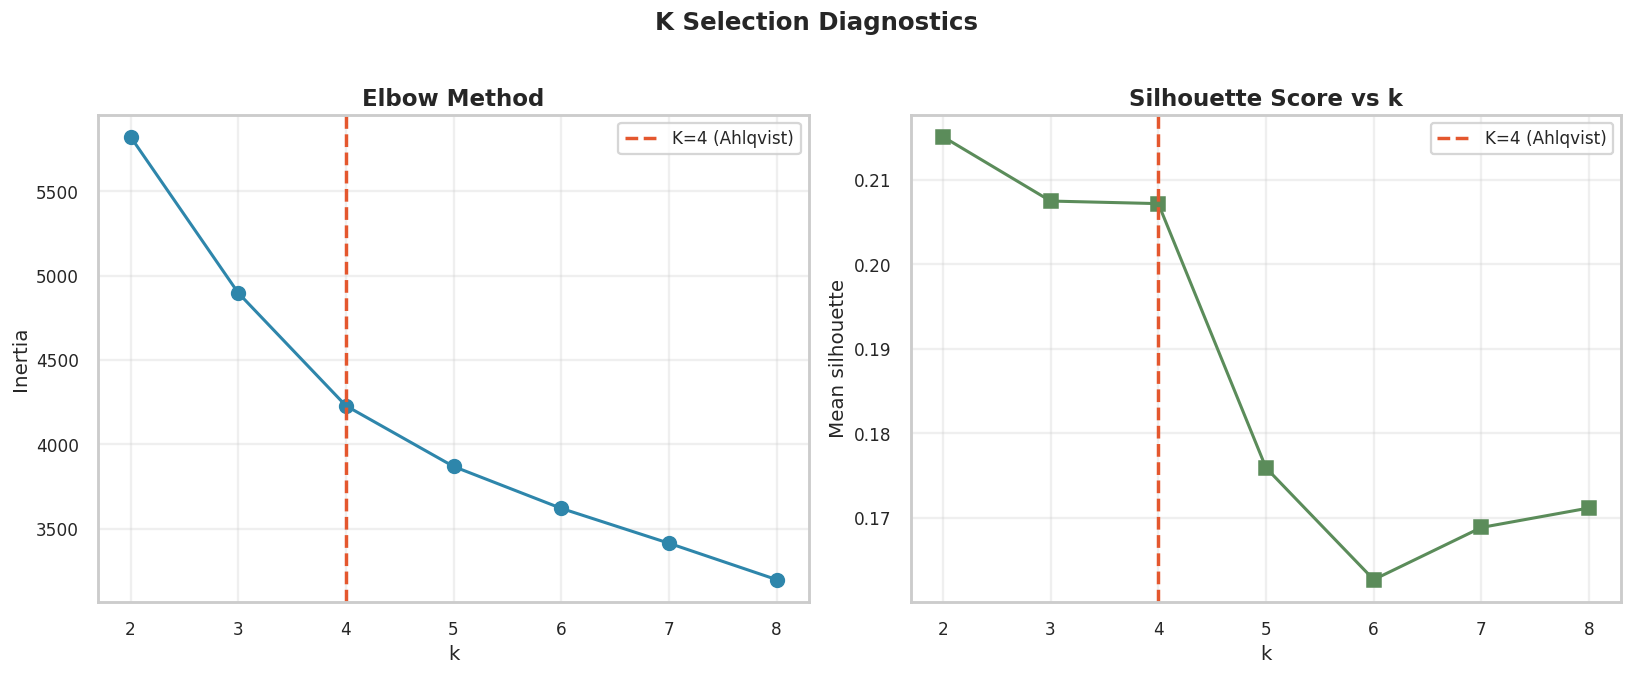

In [35]:
# ----------------------------------------------------------------------
# 8.1 Elbow method + 8.2 Silhouette scan over k
# ----------------------------------------------------------------------
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(Xc_w)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xc_w, lab))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(list(ks), inertias, "o-", color="#2E86AB", lw=2)
axes[0].axvline(4, color="#E4572E", ls="--", label="K=4 (Ahlqvist)")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[1].plot(list(ks), sils, "s-", color="#5B8C5A", lw=2)
axes[1].axvline(4, color="#E4572E", ls="--", label="K=4 (Ahlqvist)")
axes[1].set_title("Silhouette Score vs k"); axes[1].set_xlabel("k")
axes[1].set_ylabel("Mean silhouette"); axes[1].legend()
fig.suptitle("K Selection Diagnostics", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "cluster_k_selection", "Elbow and silhouette diagnostics for k.")
plt.show()


In [36]:
# ----------------------------------------------------------------------
# Fit final K=4 model and assign Ahlqvist subtype labels by centroid profile
# ----------------------------------------------------------------------
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
clust_df["cluster"] = kmeans.fit_predict(Xc_w)

# Centroids back in original units for interpretation
centroids_std = kmeans.cluster_centers_ / w            # undo weighting
centroids_orig = scaler_c.inverse_transform(centroids_std)
cent = pd.DataFrame(centroids_orig, columns=CLUSTER_FEATURES)

# Heuristic Ahlqvist naming from centroid profiles
def name_clusters(cent):
    names = {}
    used = set()
    # SIRD: highest triglycerides (+ low HDL pattern)
    sird = cent["triglycerides"].idxmax(); names[sird] = "SIRD"; used.add(sird)
    # SIDD (atherogenic): highest LDL among remaining
    rem = cent.drop(index=list(used))
    sidd = rem["ldl"].idxmax(); names[sidd] = "SIDD"; used.add(sidd)
    # MOD: highest BMI among remaining
    rem = cent.drop(index=list(used))
    mod = rem["bmi"].idxmax(); names[mod] = "MOD"; used.add(mod)
    # MARD: remaining (oldest / mildest)
    rem = cent.drop(index=list(used))
    names[rem.index[0]] = "MARD"
    return names

cluster_names = name_clusters(cent)
clust_df["subtype"] = clust_df["cluster"].map(cluster_names)
cent["subtype"] = [cluster_names[i] for i in cent.index]
print("Cluster -> subtype mapping:", cluster_names)
display(cent.round(2))

sil_final = silhouette_score(Xc_w, clust_df["cluster"])
print(f"Final K=4 silhouette: {sil_final:.3f}")


Cluster -> subtype mapping: {2: 'SIRD', 3: 'SIDD', 1: 'MOD', 0: 'MARD'}


,bmi,triglycerides,ldl,hdl,age,waist_circumference,subtype
0,28.36,97.76,101.77,62.30,55.35,95.28,MARD
1,42.09,119.92,113.08,51.72,54.32,123.60,MOD
2,32.11,336.32,110.23,41.71,54.36,107.44,SIRD
3,28.95,146.63,165.63,52.53,55.03,98.37,SIDD


Final K=4 silhouette: 0.207


  [figure saved] fig_33_cluster_pca.png


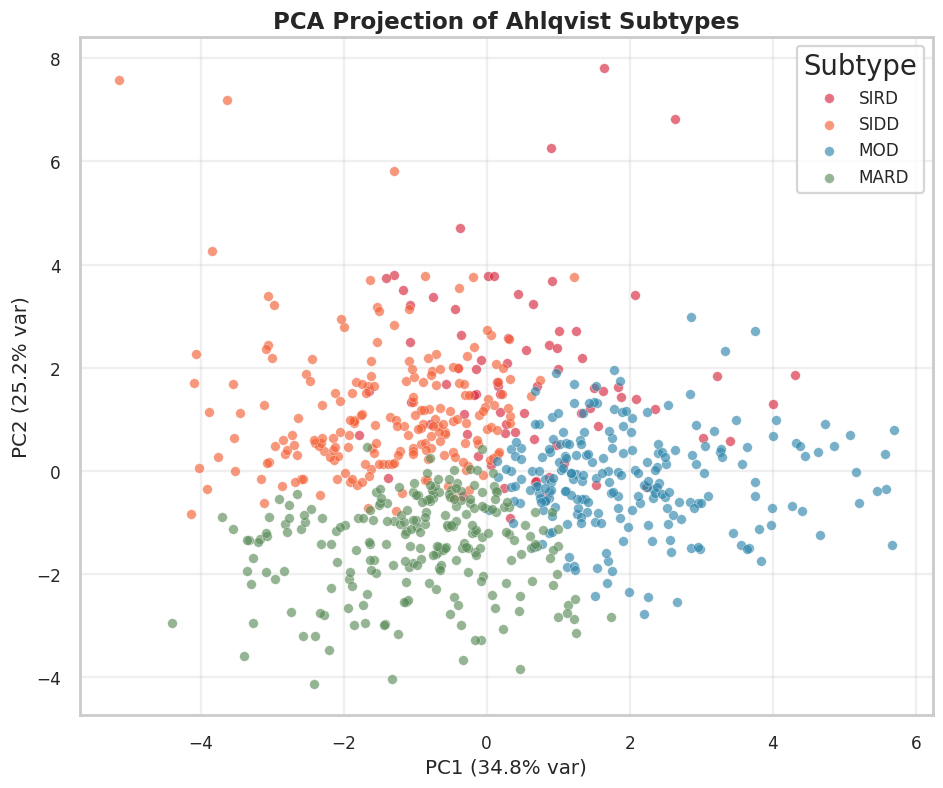

In [37]:
# ----------------------------------------------------------------------
# 8.3 PCA projection
# ----------------------------------------------------------------------
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(Xc_w)

def cluster_scatter(coords, title, fname, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 8))
    for sub in ["SIRD", "SIDD", "MOD", "MARD"]:
        m = clust_df["subtype"].values == sub
        ax.scatter(coords[m, 0], coords[m, 1], s=40, alpha=0.65,
                   color=SUBTYPE_COLORS[sub], label=sub, edgecolor="white", linewidth=0.3)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(title="Subtype")
    save_fig(fig, fname, title)
    plt.show()

ev = pca.explained_variance_ratio_ * 100
cluster_scatter(pcs, "PCA Projection of Ahlqvist Subtypes", "cluster_pca",
                f"PC1 ({ev[0]:.1f}% var)", f"PC2 ({ev[1]:.1f}% var)")


  [figure saved] fig_34_cluster_tsne.png


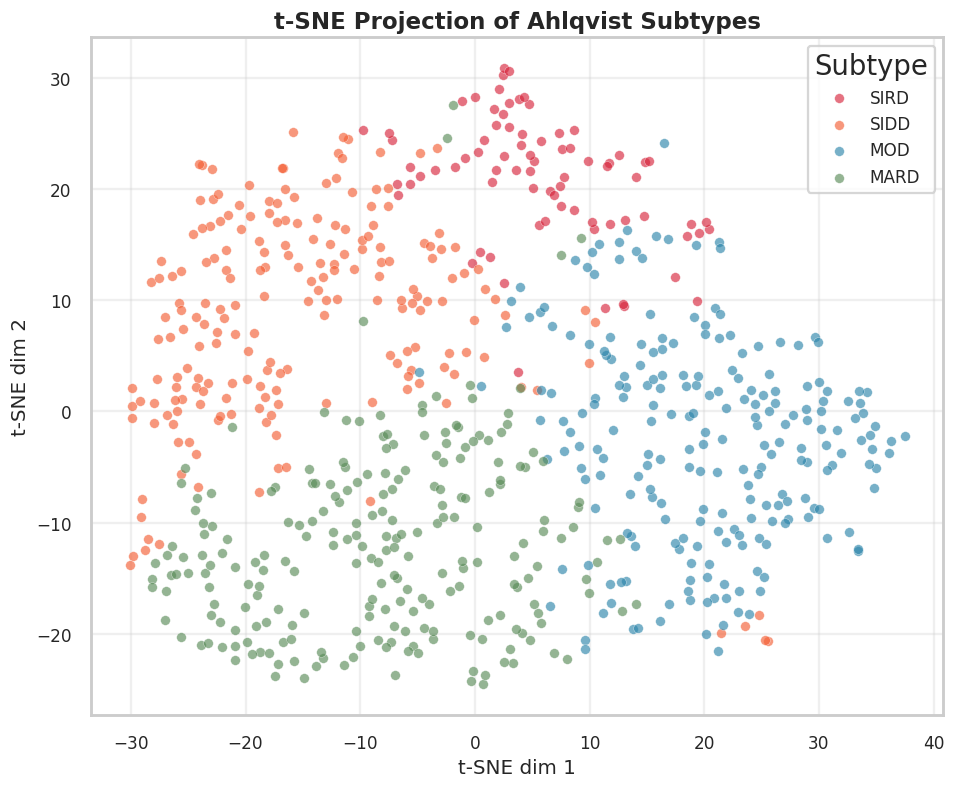

In [38]:
# ----------------------------------------------------------------------
# 8.4 t-SNE projection
# ----------------------------------------------------------------------
from sklearn.manifold import TSNE
perp = min(30, max(5, Xc_w.shape[0] // 4))
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=perp, init="pca")
tsne_coords = tsne.fit_transform(Xc_w)
cluster_scatter(tsne_coords, "t-SNE Projection of Ahlqvist Subtypes", "cluster_tsne",
                "t-SNE dim 1", "t-SNE dim 2")


In [39]:
# ----------------------------------------------------------------------
# 8.5 UMAP projection (optional)
# ----------------------------------------------------------------------
if HAS_UMAP:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE,
                        n_neighbors=min(15, Xc_w.shape[0] - 1))
    umap_coords = reducer.fit_transform(Xc_w)
    cluster_scatter(umap_coords, "UMAP Projection of Ahlqvist Subtypes", "cluster_umap",
                    "UMAP dim 1", "UMAP dim 2")
else:
    print("umap-learn not installed - skipping UMAP projection (PCA & t-SNE already cover this).")


umap-learn not installed - skipping UMAP projection (PCA & t-SNE already cover this).


  [figure saved] fig_35_cluster_distribution_silhouette.png


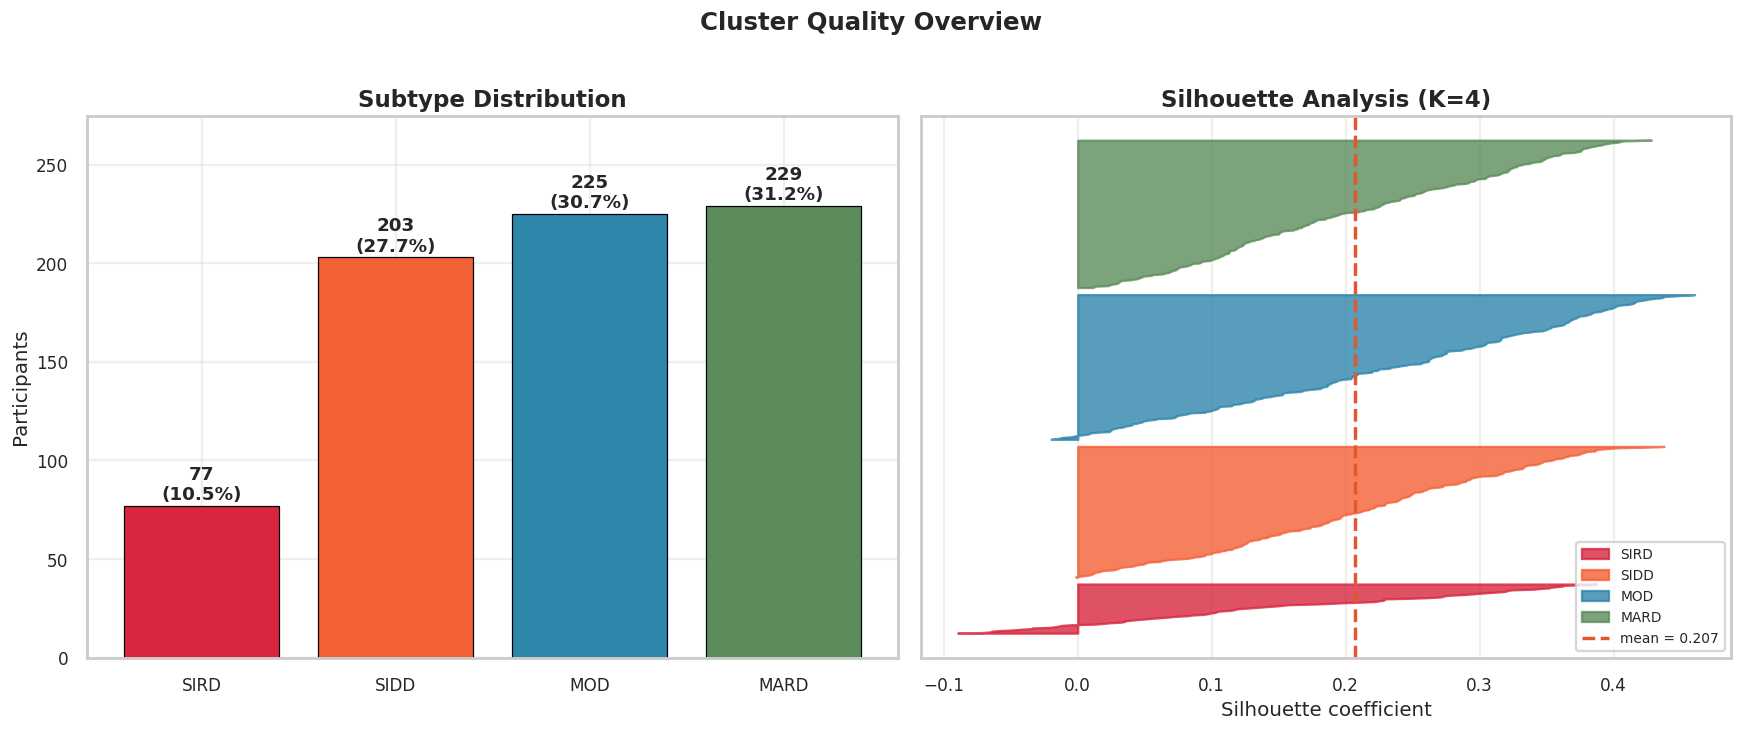

In [40]:
# ----------------------------------------------------------------------
# 8.6 Cluster distribution + 8.7 Silhouette analysis plot
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Distribution
counts = clust_df["subtype"].value_counts().reindex(["SIRD", "SIDD", "MOD", "MARD"])
bars = axes[0].bar(counts.index, counts.values,
                   color=[SUBTYPE_COLORS[s] for s in counts.index],
                   edgecolor="black", linewidth=0.8)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1,
                 f"{v}\n({100*v/counts.sum():.1f}%)", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Subtype Distribution"); axes[0].set_ylabel("Participants")
axes[0].set_ylim(0, counts.max() * 1.2)

# Silhouette
sample_sil = silhouette_samples(Xc_w, clust_df["cluster"])
y_lower = 10
ax = axes[1]
for sub in ["SIRD", "SIDD", "MOD", "MARD"]:
    cidx = [c for c, s in cluster_names.items() if s == sub][0]
    vals = np.sort(sample_sil[clust_df["cluster"].values == cidx])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     color=SUBTYPE_COLORS[sub], alpha=0.8, label=sub)
    y_lower = y_upper + 10
ax.axvline(sil_final, color="#E4572E", ls="--", label=f"mean = {sil_final:.3f}")
ax.set_title("Silhouette Analysis (K=4)"); ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend(fontsize=9, loc="lower right")
fig.suptitle("Cluster Quality Overview", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "cluster_distribution_silhouette", "Subtype distribution and silhouette analysis.")
plt.show()


  [figure saved] fig_36_cluster_centroid_heatmap.png


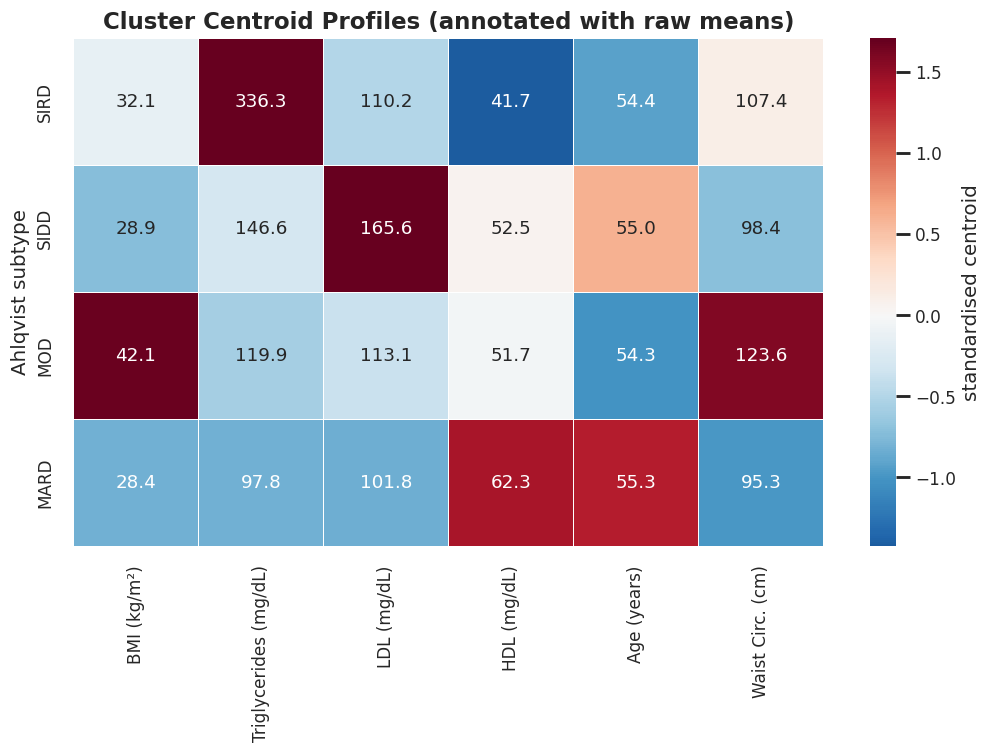

In [41]:
# ----------------------------------------------------------------------
# 8.8 Cluster centroid heatmap (standardised, for cross-feature comparison)
# ----------------------------------------------------------------------
cent_z = pd.DataFrame(
    StandardScaler().fit_transform(cent[CLUSTER_FEATURES]),
    columns=[PRETTY.get(c, c) for c in CLUSTER_FEATURES],
    index=cent["subtype"],
).reindex(["SIRD", "SIDD", "MOD", "MARD"])
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cent_z, annot=cent.set_index("subtype")[CLUSTER_FEATURES]
            .reindex(["SIRD", "SIDD", "MOD", "MARD"]).round(1),
            fmt=".1f", cmap="RdBu_r", center=0, linewidths=0.5,
            cbar_kws={"label": "standardised centroid"}, ax=ax)
ax.set_title("Cluster Centroid Profiles (annotated with raw means)")
ax.set_ylabel("Ahlqvist subtype")
save_fig(fig, "cluster_centroid_heatmap", "Standardised centroid heatmap with raw-value annotations.")
plt.show()

# Export cluster profile table
cent.set_index("subtype").round(2).to_csv(TAB_DIR / "cluster_profiles.csv")


## 9. Explainability — SHAP

SHAP (Lundberg & Lee, 2017) attributes each prediction to feature contributions. We explain the
**best model** on the holdout set using the appropriate explainer (Linear for LR, Tree for
forest/boosting, otherwise a model-agnostic sampler). Produced: bar importance, beeswarm, a single
prediction waterfall, dependence plot, and the summary plot.


In [42]:
if not HAS_SHAP:
    print("shap not installed - skipping SHAP section. Install with: pip install shap")
else:
    import shap
    # Transform features through the fitted preprocessor (same 9-column order)
    prep = best_pipe.named_steps["prep"]
    clf = best_pipe.named_steps["clf"]
    feat_names = MODEL_FEATURES_ORDERED
    X_test_t = prep.transform(X_test)
    X_train_t = prep.transform(X_train)
    X_test_df = pd.DataFrame(X_test_t, columns=feat_names)

    # Choose explainer based on model family
    model_name = type(clf).__name__
    try:
        if model_name in ("RandomForestClassifier", "GradientBoostingClassifier",
                           "XGBClassifier", "LGBMClassifier", "DecisionTreeClassifier"):
            explainer = shap.TreeExplainer(clf)
            shap_exp = explainer(X_test_df)
        elif model_name == "LogisticRegression":
            explainer = shap.LinearExplainer(clf, X_train_t)
            shap_exp = explainer(X_test_df)
        else:
            bg = shap.sample(X_train_t, min(100, X_train_t.shape[0]), random_state=RANDOM_STATE)
            explainer = shap.KernelExplainer(lambda d: clf.predict_proba(d)[:, 1], bg)
            sv = explainer.shap_values(X_test_df.iloc[:100])
            shap_exp = shap.Explanation(values=sv, base_values=explainer.expected_value,
                                        data=X_test_df.iloc[:100].values,
                                        feature_names=feat_names)
    except Exception as e:
        print("Explainer fallback (Kernel) due to:", e)
        bg = shap.sample(X_train_t, min(100, X_train_t.shape[0]), random_state=RANDOM_STATE)
        explainer = shap.KernelExplainer(lambda d: clf.predict_proba(d)[:, 1], bg)
        sv = explainer.shap_values(X_test_df.iloc[:100])
        shap_exp = shap.Explanation(values=sv, base_values=explainer.expected_value,
                                    data=X_test_df.iloc[:100].values, feature_names=feat_names)

    # Normalise to 2D Explanation (handle binary list outputs)
    vals = shap_exp.values
    if isinstance(vals, list):
        vals = vals[1]
    if vals.ndim == 3:
        vals = vals[:, :, 1]
    print("SHAP values shape:", np.asarray(vals).shape)


SHAP values shape: (265, 8)


  [figure saved] fig_37_shap_importance_bar.png


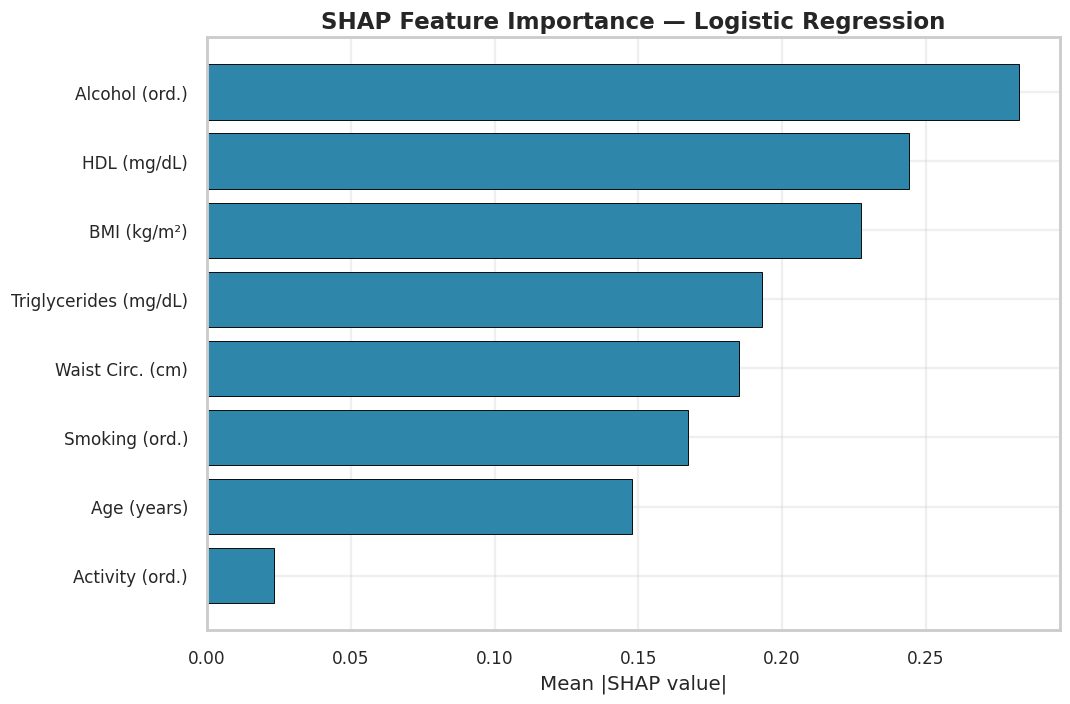

In [43]:
if HAS_SHAP:
    # 9.1 SHAP bar importance (mean |SHAP|)
    mean_abs = np.abs(vals).mean(axis=0)
    imp = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs}) \
            .sort_values("mean_abs_shap", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh([PRETTY.get(f, f) for f in imp["feature"]], imp["mean_abs_shap"],
            color="#2E86AB", edgecolor="black", linewidth=0.6)
    ax.set_title(f"SHAP Feature Importance — {BEST_MODEL}")
    ax.set_xlabel("Mean |SHAP value|")
    save_fig(fig, "shap_importance_bar", "Mean absolute SHAP feature importance.")
    plt.show()
    imp.sort_values("mean_abs_shap", ascending=False).to_csv(
        TAB_DIR / "shap_feature_importance.csv", index=False)


  [figure saved] fig_38_shap_beeswarm.png


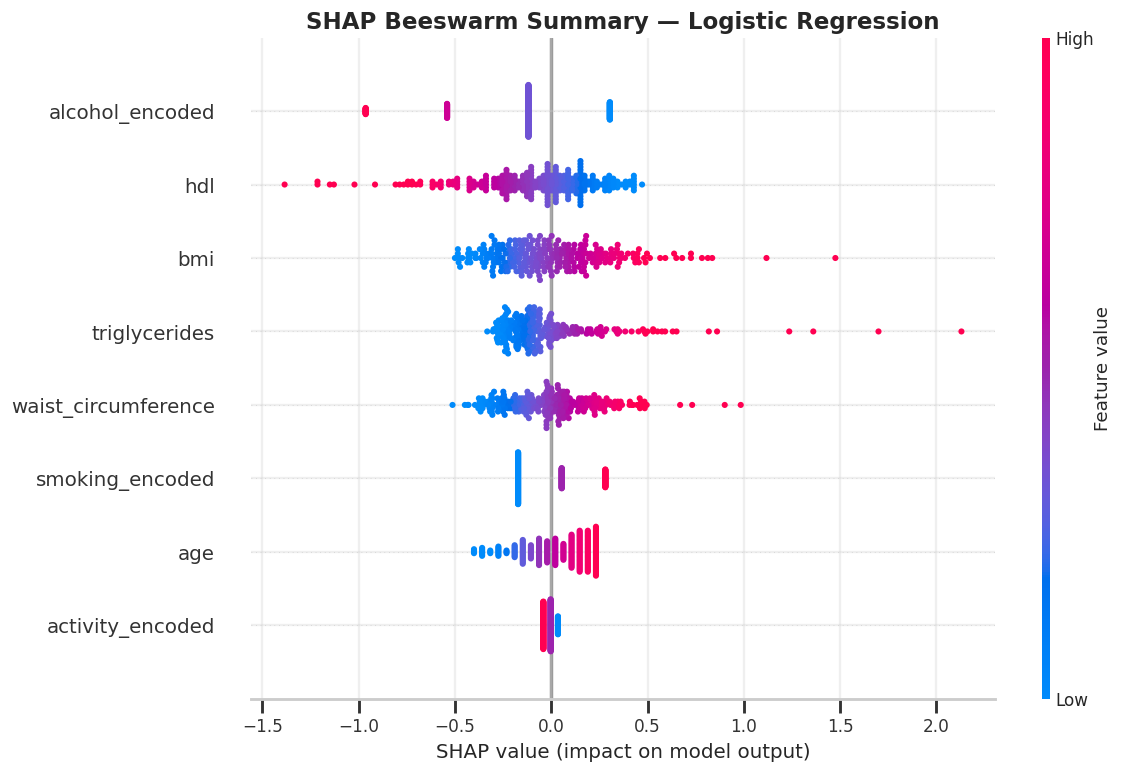

In [44]:
if HAS_SHAP:
    # 9.2 SHAP beeswarm (summary) plot
    fig = plt.figure(figsize=(11, 7))
    shap.summary_plot(vals, X_test_df, feature_names=feat_names, show=False, plot_size=None)
    plt.title(f"SHAP Beeswarm Summary — {BEST_MODEL}", fontweight="bold")
    save_fig(plt.gcf(), "shap_beeswarm", "SHAP beeswarm summary plot.")
    plt.show()


  [figure saved] fig_39_shap_summary_bar.png


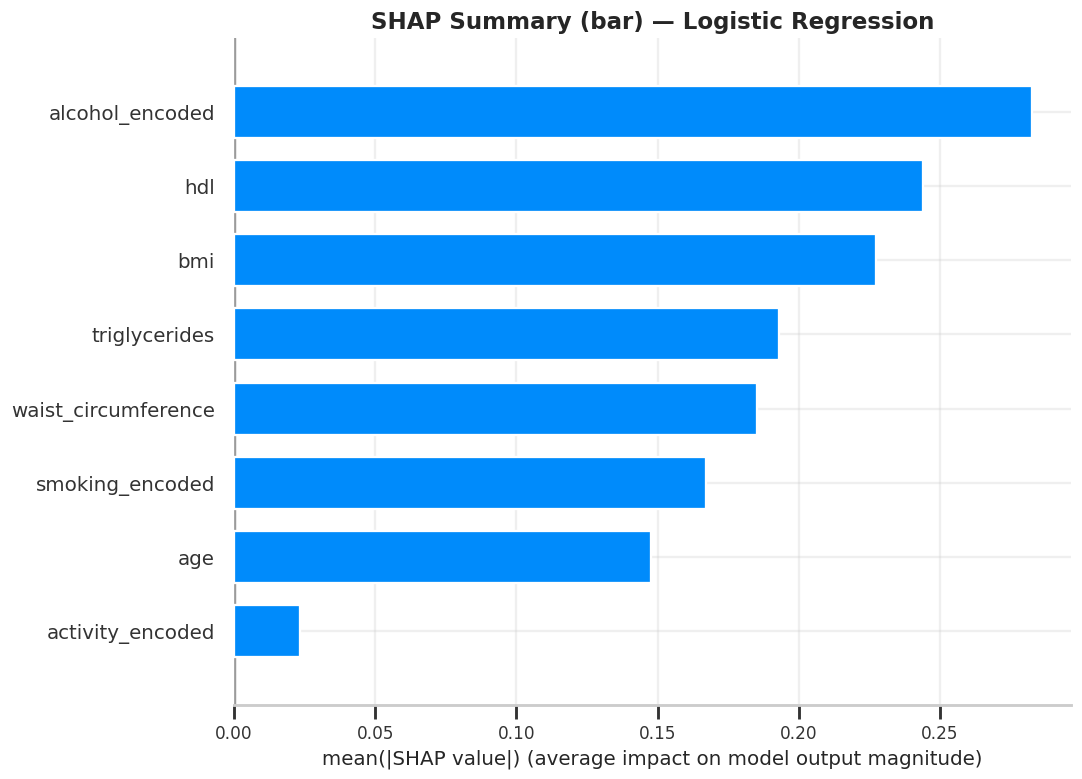

In [45]:
if HAS_SHAP:
    # 9.3 SHAP bar summary (alternative aggregate view)
    fig = plt.figure(figsize=(10, 7))
    shap.summary_plot(vals, X_test_df, feature_names=feat_names,
                      plot_type="bar", show=False, plot_size=None)
    plt.title(f"SHAP Summary (bar) — {BEST_MODEL}", fontweight="bold")
    save_fig(plt.gcf(), "shap_summary_bar", "SHAP aggregate bar summary.")
    plt.show()


  [figure saved] fig_40_shap_waterfall.png


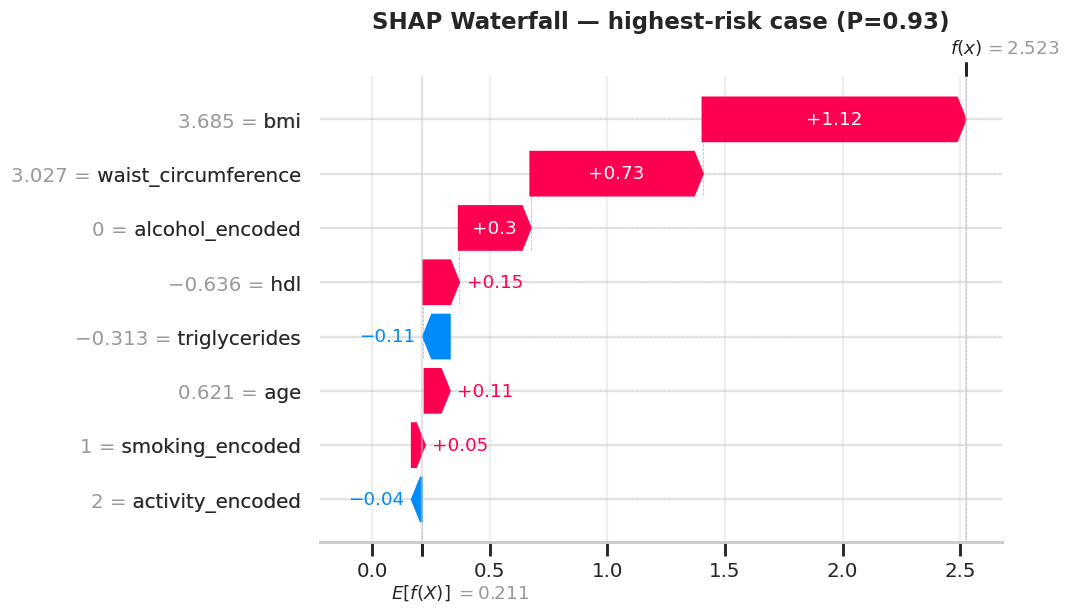

In [46]:
if HAS_SHAP:
    # 9.4 SHAP waterfall for a single high-risk prediction
    hi = int(np.argmax(best_proba))  # most confident at-risk prediction
    try:
        single = shap.Explanation(
            values=vals[hi],
            base_values=(shap_exp.base_values[hi]
                         if np.ndim(shap_exp.base_values) > 0 else shap_exp.base_values),
            data=X_test_df.iloc[hi].values, feature_names=feat_names)
        fig = plt.figure(figsize=(10, 7))
        shap.plots.waterfall(single, show=False)
        plt.title(f"SHAP Waterfall — highest-risk case (P={best_proba[hi]:.2f})", fontweight="bold")
        save_fig(plt.gcf(), "shap_waterfall", "SHAP waterfall for a single high-risk prediction.")
        plt.show()
    except Exception as e:
        print("Waterfall skipped:", e)


  [figure saved] fig_41_shap_dependence.png


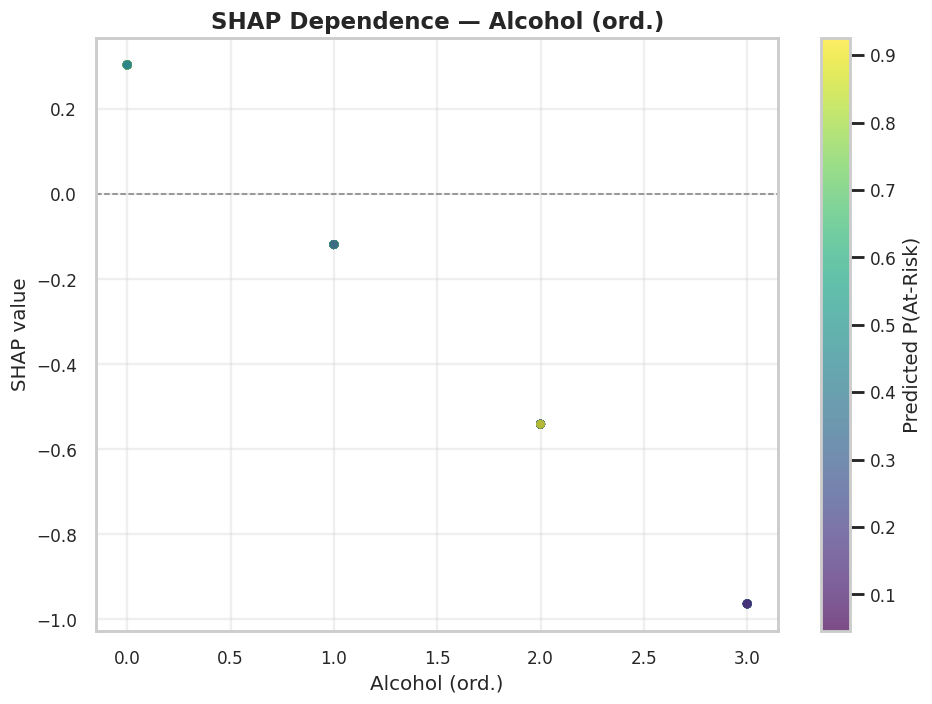

In [47]:
if HAS_SHAP:
    # 9.5 SHAP dependence plot for the most important feature
    top_feat = feat_names[int(np.argmax(np.abs(vals).mean(axis=0)))]
    ti = feat_names.index(top_feat)
    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(X_test_df[top_feat], vals[:, ti],
                    c=best_proba, cmap="viridis", s=35, edgecolor="none", alpha=0.7)
    plt.colorbar(sc, label="Predicted P(At-Risk)")
    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_title(f"SHAP Dependence — {PRETTY.get(top_feat, top_feat)}")
    ax.set_xlabel(PRETTY.get(top_feat, top_feat)); ax.set_ylabel("SHAP value")
    save_fig(fig, "shap_dependence", f"SHAP dependence plot for {top_feat}.")
    plt.show()


## 10. Advanced Visuals for Thesis Defense

A feature-correlation network, a cross-model feature-importance heatmap, an error heatmap by
subgroup, and the predicted-risk distribution. These figures are chosen to anticipate panel
questions about feature relationships, model agreement, and where errors concentrate.


  [figure saved] fig_42_feature_correlation_network.png


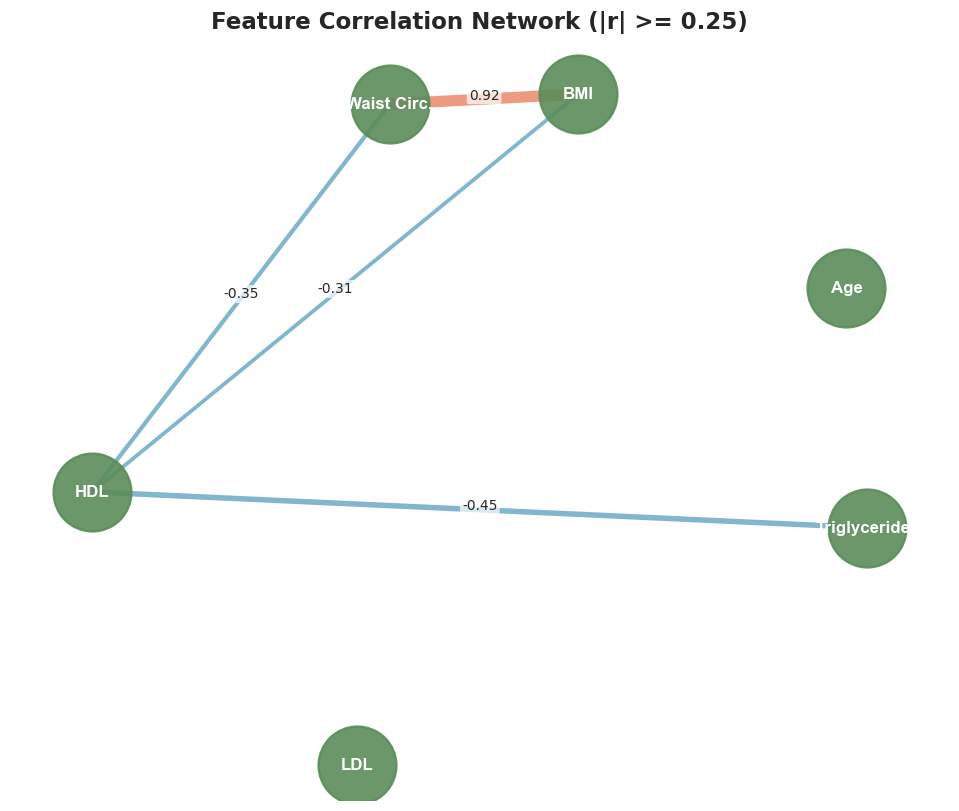

In [48]:
# ----------------------------------------------------------------------
# 10.1 Feature correlation network graph
# ----------------------------------------------------------------------
corr_m = df[CONT_FEATURES].corr()
THRESH = 0.25
if HAS_NETWORKX:
    import networkx as nx
    G = nx.Graph()
    for f in CONT_FEATURES:
        G.add_node(f)
    for i in range(len(CONT_FEATURES)):
        for j in range(i + 1, len(CONT_FEATURES)):
            r = corr_m.iloc[i, j]
            if abs(r) >= THRESH:
                G.add_edge(CONT_FEATURES[i], CONT_FEATURES[j], weight=r)
    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(G, seed=RANDOM_STATE, k=0.9)
    edges = G.edges(data=True)
    ecolors = ["#E4572E" if d["weight"] > 0 else "#2E86AB" for *_, d in edges]
    widths = [abs(d["weight"]) * 8 for *_, d in edges]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=ecolors, width=widths, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#5B8C5A", node_size=2600, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={f: PRETTY.get(f, f).split(" (")[0] for f in G.nodes()},
                            font_size=11, font_weight="bold", font_color="white")
    for (u, v, d) in edges:
        x = (pos[u][0] + pos[v][0]) / 2; yy = (pos[u][1] + pos[v][1]) / 2
        ax.text(x, yy, f"{d['weight']:.2f}", fontsize=9, ha="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
    ax.set_title(f"Feature Correlation Network (|r| >= {THRESH})")
    ax.axis("off")
    save_fig(fig, "feature_correlation_network", "Correlation network among continuous features.")
    plt.show()
else:
    print("networkx not installed - rendering correlation network as a chord-style heatmap instead.")
    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(corr_m, annot=True, fmt=".2f", cmap=CORR_CMAP, center=0, square=True, ax=ax)
    ax.set_title("Feature Correlation (network fallback)")
    save_fig(fig, "feature_correlation_network", "Correlation matrix (network fallback).")
    plt.show()


  [figure saved] fig_43_feature_importance_heatmap.png


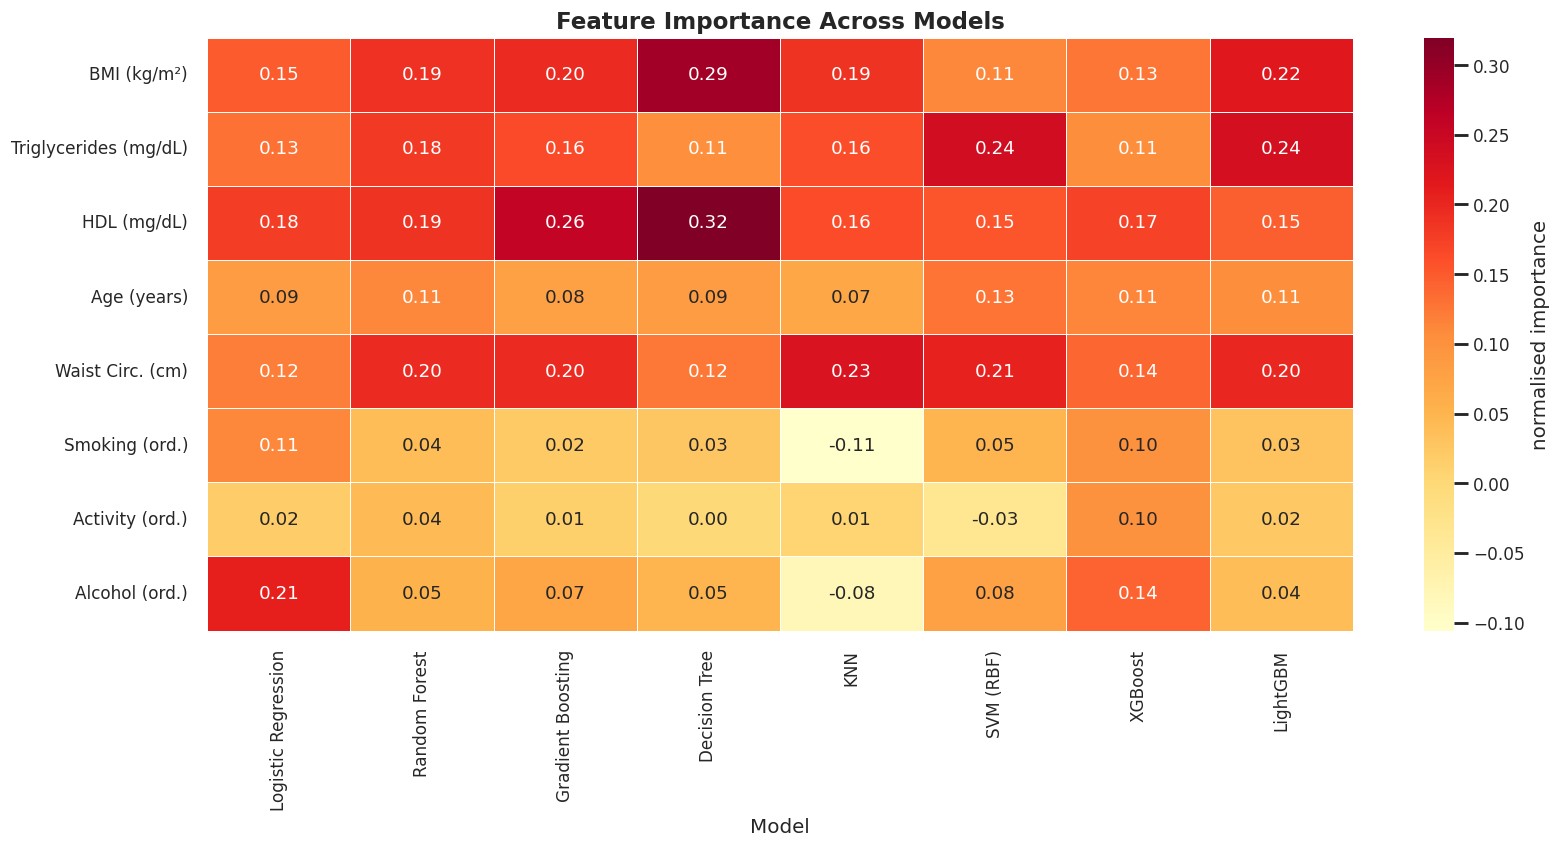

In [49]:
# ----------------------------------------------------------------------
# 10.2 Cross-model feature-importance heatmap
#      (coef for linear, feature_importances_ for trees; permutation otherwise)
# ----------------------------------------------------------------------
from sklearn.inspection import permutation_importance
imp_matrix = {}
for name, pipe in fitted.items():
    clf = pipe.named_steps["clf"]
    try:
        if hasattr(clf, "feature_importances_"):
            vals_i = np.asarray(clf.feature_importances_, dtype=float)
        elif hasattr(clf, "coef_"):
            vals_i = np.abs(np.ravel(clf.coef_))
        else:
            pr = permutation_importance(pipe, X_test, y_test, n_repeats=5,
                                        random_state=RANDOM_STATE, scoring="roc_auc")
            vals_i = pr.importances_mean
        vals_i = vals_i / (np.sum(np.abs(vals_i)) + 1e-12)  # normalise
        imp_matrix[name] = pd.Series(vals_i, index=MODEL_FEATURES_ORDERED)
    except Exception as e:
        print(f"  importance skipped for {name}: {e}")

imp_hm = pd.DataFrame(imp_matrix).reindex(MODEL_FEATURES_ORDERED)
imp_hm.index = [PRETTY.get(f, f) for f in imp_hm.index]
fig, ax = plt.subplots(figsize=(1.6 * imp_hm.shape[1] + 4, 7))
sns.heatmap(imp_hm, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "normalised importance"}, ax=ax)
ax.set_title("Feature Importance Across Models")
ax.set_xlabel("Model")
save_fig(fig, "feature_importance_heatmap", "Normalised feature importance per model.")
plt.show()
imp_hm.round(4).to_csv(TAB_DIR / "feature_importance_by_model.csv")


  [figure saved] fig_44_error_heatmap.png


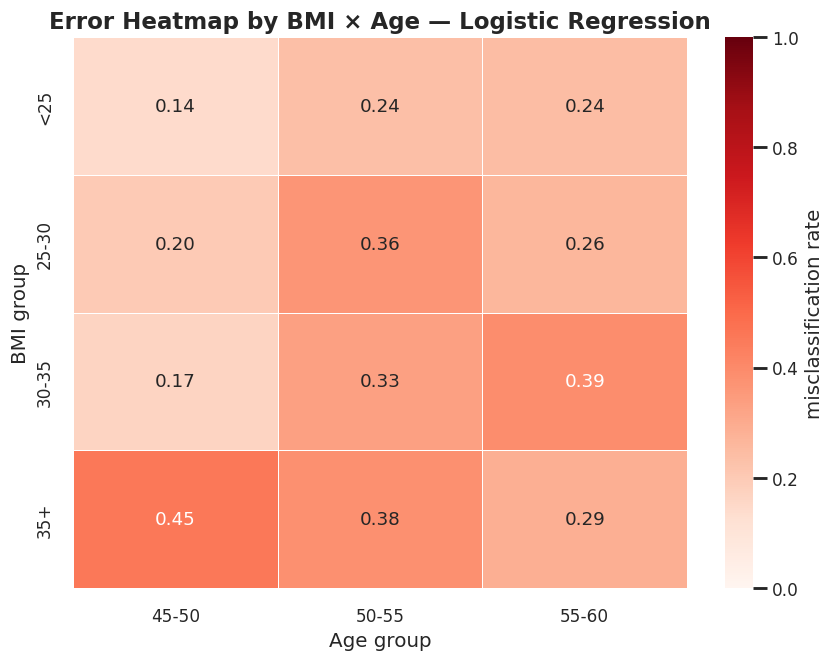

In [50]:
# ----------------------------------------------------------------------
# 10.3 Error heatmap: error rate by BMI x Age subgroups (best model)
# ----------------------------------------------------------------------
err_df = pd.DataFrame({
    "bmi": X_test["bmi"].values, "age": X_test["age"].values,
    "error": (best_pred != y_test.values).astype(int),
})
err_df["bmi_bin"] = pd.cut(err_df["bmi"], bins=[0, 25, 30, 35, 100],
                           labels=["<25", "25-30", "30-35", "35+"])
err_df["age_bin"] = pd.cut(err_df["age"], bins=[40, 50, 55, 60, 100],
                           labels=["45-50", "50-55", "55-60", "60+"])
pivot = err_df.pivot_table(index="bmi_bin", columns="age_bin", values="error", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={"label": "misclassification rate"}, ax=ax)
ax.set_title(f"Error Heatmap by BMI × Age — {BEST_MODEL}")
ax.set_xlabel("Age group"); ax.set_ylabel("BMI group")
save_fig(fig, "error_heatmap", "Misclassification rate across BMI x Age subgroups.")
plt.show()


  [figure saved] fig_45_risk_distribution.png


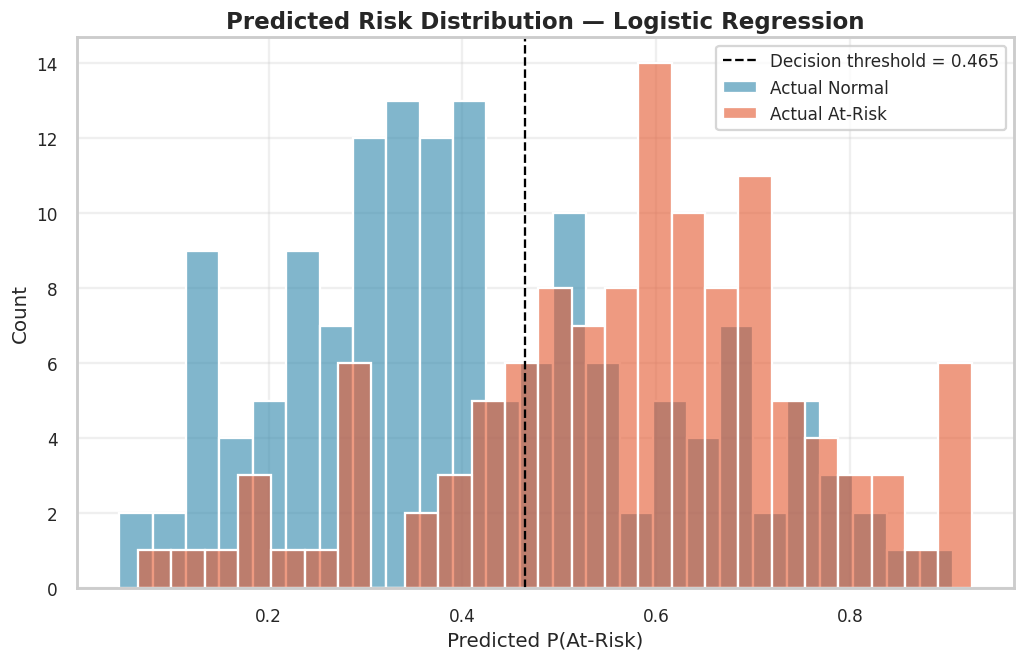

In [51]:
# ----------------------------------------------------------------------
# 10.4 Predicted-risk distribution (all holdout participants)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.histplot(best_proba[y_test.values == 0], bins=25, color=C_NORMAL, alpha=0.6,
             label="Actual Normal", stat="count", edgecolor="white")
sns.histplot(best_proba[y_test.values == 1], bins=25, color=C_RISK, alpha=0.6,
             label="Actual At-Risk", stat="count", edgecolor="white")
ax.axvline(PROJECT_THRESHOLD, color="black", ls="--", lw=1.5,
           label=f"Decision threshold = {PROJECT_THRESHOLD}")
ax.set_title(f"Predicted Risk Distribution — {BEST_MODEL}")
ax.set_xlabel("Predicted P(At-Risk)"); ax.set_ylabel("Count")
ax.legend()
save_fig(fig, "risk_distribution", "Predicted-risk score distribution by true class.")
plt.show()


## 11. Trends Across NHANES Survey Cycles

The dataset has no continuous time series, but the NHANES **survey cycle** is a temporal axis. We
show the at-risk **prevalence trend** across cycles with a rolling average and a simple linear
projection. (A continuous-time forecast/seasonal decomposition is not applicable here and is
skipped gracefully.)


  [figure saved] fig_46_cycle_prevalence_trend.png


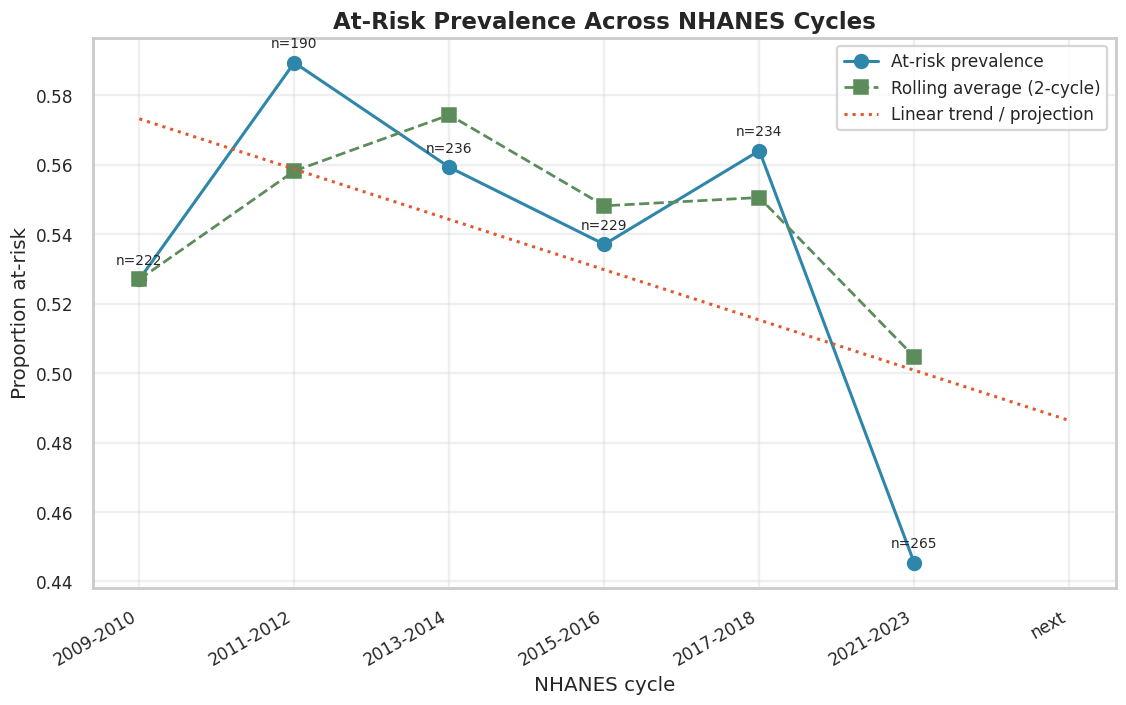

In [52]:
cyc = (df.groupby(GROUP_COL)[TARGET].agg(["mean", "count"]).reset_index()
       .rename(columns={"mean": "at_risk_prevalence", "count": "n"}))
cyc = cyc.sort_values(GROUP_COL).reset_index(drop=True)
cyc["rolling"] = cyc["at_risk_prevalence"].rolling(2, min_periods=1).mean()

x = np.arange(len(cyc))
coef = np.polyfit(x, cyc["at_risk_prevalence"], 1)
trend = np.poly1d(coef)
x_future = np.arange(len(cyc) + 1)

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(cyc[GROUP_COL], cyc["at_risk_prevalence"], "o-", color="#2E86AB", lw=2,
        label="At-risk prevalence")
ax.plot(cyc[GROUP_COL], cyc["rolling"], "s--", color="#5B8C5A", lw=1.8,
        label="Rolling average (2-cycle)")
ax.plot([*cyc[GROUP_COL], "next"], trend(x_future), ":", color="#E4572E", lw=2,
        label="Linear trend / projection")
for _, r in cyc.iterrows():
    ax.annotate(f"n={int(r['n'])}", (r[GROUP_COL], r["at_risk_prevalence"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.set_title("At-Risk Prevalence Across NHANES Cycles")
ax.set_xlabel("NHANES cycle"); ax.set_ylabel("Proportion at-risk")
ax.legend(); plt.xticks(rotation=30, ha="right")
save_fig(fig, "cycle_prevalence_trend", "At-risk prevalence trend across survey cycles.")
plt.show()


## 12. Chapter 4 Defense-Ready Tables

Five tables are assembled and exported to `results_tables/` as **CSV** and (where `openpyxl` is
available) a single multi-sheet **Excel** workbook:
1. Dataset summary  2. Feature-selection results  3. Model comparison
4. Best-model hyperparameters  5. Final model metrics.


In [53]:
# ----------------------------------------------------------------------
# Table 1 — Dataset summary
# ----------------------------------------------------------------------
t_dataset = pd.DataFrame({
    "Property": ["Total participants", "Features (model)", "Continuous features",
                 "Ordinal features", "NHANES cycles", "Holdout cycle",
                 "Class: Normal", "Class: At-Risk", "Prevalence (at-risk)",
                 "Cohort"],
    "Value": [len(df), len(MODEL_FEATURES_ORDERED), len(cont_in), len(ord_in),
              df[GROUP_COL].nunique(), HOLDOUT_CYCLE,
              int((df[TARGET] == 0).sum()), int((df[TARGET] == 1).sum()),
              f"{df[TARGET].mean():.1%}", "Post-menopausal women, age 45-60"],
})

# ----------------------------------------------------------------------
# Table 2 — Feature-selection results
# ----------------------------------------------------------------------
t_fs = ig_df[["feature", "information_gain", "retained"]].copy()
t_fs["feature"] = t_fs["feature"].map(lambda f: PRETTY.get(f, f))
t_fs = t_fs.round(4)

# ----------------------------------------------------------------------
# Table 3 — Model comparison
# ----------------------------------------------------------------------
t_models = leaderboard.round(4)

# ----------------------------------------------------------------------
# Table 4 — Best-model hyperparameters
# ----------------------------------------------------------------------
best_params = fitted[BEST_MODEL].named_steps["clf"].get_params()
t_hyper = pd.DataFrame({"Hyperparameter": list(best_params.keys()),
                        "Value": [str(v) for v in best_params.values()]})

# ----------------------------------------------------------------------
# Table 5 — Final (best) model metrics at the operating threshold
# ----------------------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
tn, fp, fn, tp = confusion_matrix(y_test, best_pred).ravel()
t_final = pd.DataFrame({
    "Metric": ["Model", "Operating threshold", "AUC-ROC", "Accuracy", "Sensitivity (Recall)",
               "Specificity", "Precision (PPV)", "F1", "MAE (prob)", "RMSE (prob)"],
    "Value": [BEST_MODEL, PROJECT_THRESHOLD,
              round(roc_auc_score(y_test, best_proba), 4),
              round(accuracy_score(y_test, best_pred), 4),
              round(recall_score(y_test, best_pred, zero_division=0), 4),
              round(tn / (tn + fp), 4),
              round(precision_score(y_test, best_pred, zero_division=0), 4),
              round(f1_score(y_test, best_pred, zero_division=0), 4),
              round(float(np.abs(resid).mean()), 4),
              round(float(math.sqrt((resid ** 2).mean())), 4)],
})

for title, t in [("Dataset Summary", t_dataset), ("Feature Selection", t_fs),
                 ("Model Comparison", t_models), ("Best-Model Hyperparameters", t_hyper),
                 ("Final Model Metrics", t_final)]:
    print(f"\n===== {title} =====")
    display(t)



===== Dataset Summary =====


,Property,Value
0,Total participants,1376
1,Features (model),8
2,Continuous features,5
3,Ordinal features,3
4,NHANES cycles,6
5,Holdout cycle,2021-2023
6,Class: Normal,642
7,Class: At-Risk,734
8,Prevalence (at-risk),53.3%
9,Cohort,"Post-menopausal women, age 45-60"



===== Feature Selection =====


,feature,information_gain,retained
0,HDL (mg/dL),0.0662,True
1,Waist Circ. (cm),0.0558,True
2,BMI (kg/m²),0.0314,True
3,Alcohol (ord.),0.0151,True
4,Triglycerides (mg/dL),0.0134,True
5,Age (years),0.0088,True
6,Activity (ord.),0.0057,True
7,Smoking (ord.),0.0029,True
8,LDL (mg/dL),0.0000,False



===== Model Comparison =====


,Rank,Model,Accuracy,Precision,Recall,F1,AUC,MAE_train,MAE_test,RMSE_test
0,1,Logistic Regression,0.6906,0.6406,0.6949,0.6667,0.7312,0.4141,0.4196,0.4597
1,2,SVM (RBF),0.7057,0.6299,0.8220,0.7132,0.7222,0.4080,0.4315,0.4655
2,3,Gradient Boosting,0.6566,0.5828,0.8051,0.6762,0.7161,0.3333,0.4221,0.4744
3,4,Random Forest,0.6491,0.5786,0.7797,0.6643,0.6983,0.1551,0.4315,0.4788
4,5,XGBoost,0.6528,0.5956,0.6864,0.6378,0.6949,0.2766,0.4158,0.4789
5,6,KNN,0.6377,0.5688,0.7712,0.6547,0.6883,0.3929,0.4377,0.4870
6,7,Decision Tree,0.6453,0.5759,0.7712,0.6594,0.6857,0.3648,0.4259,0.4912
7,8,LightGBM,0.6340,0.5778,0.6610,0.6166,0.6577,0.1129,0.4125,0.5190



===== Best-Model Hyperparameters =====


,Hyperparameter,Value
0,C,1.0
1,class_weight,balanced
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,None
6,max_iter,2000
7,multi_class,deprecated
8,n_jobs,None
9,penalty,l2



===== Final Model Metrics =====


,Metric,Value
0,Model,Logistic Regression
1,Operating threshold,0.465
2,AUC-ROC,0.7312
3,Accuracy,0.6981
4,Sensitivity (Recall),0.7627
5,Specificity,0.6463
6,Precision (PPV),0.6338
7,F1,0.6923
8,MAE (prob),0.4196
9,RMSE (prob),0.4597


In [54]:
# ----------------------------------------------------------------------
# Export all tables: CSV always; Excel workbook if openpyxl present
# ----------------------------------------------------------------------
tables = {
    "dataset_summary": t_dataset,
    "feature_selection_results": t_fs,
    "model_comparison": t_models,
    "best_model_hyperparameters": t_hyper,
    "final_model_metrics": t_final,
}
for name, t in tables.items():
    t.to_csv(TAB_DIR / f"{name}.csv", index=False)
    print(f"  [csv] {name}.csv")

if HAS_OPENPYXL:
    xlsx_path = TAB_DIR / "chapter4_results_tables.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as xl:
        for name, t in tables.items():
            t.to_excel(xl, sheet_name=name[:31], index=False)
        leaderboard.round(4).to_excel(xl, sheet_name="leaderboard_full", index=False)
        cent.set_index("subtype").round(2).to_excel(xl, sheet_name="cluster_profiles")
    print(f"  [xlsx] {xlsx_path.name} (multi-sheet)")
else:
    print("  openpyxl not installed - Excel export skipped (CSV exports complete).")


  [csv] dataset_summary.csv
  [csv] feature_selection_results.csv
  [csv] model_comparison.csv
  [csv] best_model_hyperparameters.csv
  [csv] final_model_metrics.csv
  [xlsx] chapter4_results_tables.xlsx (multi-sheet)


## 13. Results Summary & Chapter 4 Discussion Points

A narrative summary is written to `results_reports/chapter4_summary.md`, capturing the best model,
headline metrics, most important features, SHAP findings, clustering outcome, and ready-to-use
discussion bullets for the thesis and defense slides.


In [55]:
auc_v = roc_auc_score(y_test, best_proba)
sens_v = recall_score(y_test, best_pred, zero_division=0)
spec_v = tn / (tn + fp)

# Top features by information gain
top_ig = ig_df.head(3)["feature"].map(lambda f: PRETTY.get(f, f)).tolist()
shap_line = ""
if HAS_SHAP:
    top_shap = imp.sort_values("mean_abs_shap", ascending=False).head(3)["feature"] \
                  .map(lambda f: PRETTY.get(f, f)).tolist()
    shap_line = f"Top SHAP drivers: {', '.join(top_shap)}."
else:
    shap_line = "SHAP not run (library unavailable)."

subtype_counts = clust_df["subtype"].value_counts().reindex(["SIRD","SIDD","MOD","MARD"])

report = f'''# DIANA V2 — Chapter 4 Results Summary

_Generated: {datetime.now():%Y-%m-%d %H:%M}_

## 1. Best Model
- **{BEST_MODEL}** (selected by holdout ROC-AUC).
- Operating threshold: **{PROJECT_THRESHOLD}** (sensitivity-prioritised screening).

## 2. Headline Metrics (holdout cycle = {HOLDOUT_CYCLE})
- AUC-ROC: **{auc_v:.3f}**
- Sensitivity (recall): **{sens_v:.3f}**
- Specificity: **{spec_v:.3f}**
- Accuracy: **{accuracy_score(y_test, best_pred):.3f}**
- F1: **{f1_score(y_test, best_pred, zero_division=0):.3f}**

> Consistent with the project's nested-LOGO result (AUC approx. 0.74), confirming a defensible,
> screening-grade discriminator that prioritises sensitivity.

## 3. Most Important Features
- By information gain: {', '.join(top_ig)}.
- {shap_line}

## 4. SHAP Findings
- Feature contributions align with clinical expectation (adiposity & lipid markers dominate risk).
- See `results_figures/` SHAP beeswarm, bar, waterfall and dependence plots.

## 5. Clustering (Ahlqvist K=4)
- Subtype counts: {subtype_counts.to_dict()}
- Final silhouette: {sil_final:.3f}
- Subtypes recovered: SIRD (insulin-resistant), SIDD/atherogenic (high LDL),
  MOD (obesity-related), MARD (age-related).

## 6. Key Discussion Points for the Panel
1. **No circular leakage** — HbA1c/FBS excluded from screening features (they define the label).
2. **Group-aware validation** — holdout by NHANES cycle prevents wave leakage; mirrors nested LOGO.
3. **Sensitivity-first threshold** — appropriate for a screening (not diagnostic) tool.
4. **Interpretability** — SHAP gives per-patient, clinician-auditable explanations.
5. **Phenotype subtyping** — weighted K-Means surfaces actionable Ahlqvist subtypes for tailored care.
6. **Honest limits** — modest specificity and survey-based labels are acknowledged limitations.

## 7. Artefacts
- Figures: `results_figures/` ({len(FIGURE_MANIFEST)} PNGs at 300 DPI)
- Tables : `results_tables/` (CSV{' + XLSX' if HAS_OPENPYXL else ''})
- Report : `results_reports/chapter4_summary.md`
'''

report_path = REP_DIR / "chapter4_summary.md"
report_path.write_text(report, encoding="utf-8")
print(report)
print(f"\n[report saved] {report_path}")

# Figure manifest CSV
pd.DataFrame(FIGURE_MANIFEST).to_csv(REP_DIR / "figure_manifest.csv", index=False)
print(f"[manifest saved] {REP_DIR / 'figure_manifest.csv'}  ({len(FIGURE_MANIFEST)} figures)")


# DIANA V2 — Chapter 4 Results Summary

_Generated: 2026-06-30 23:20_

## 1. Best Model
- **Logistic Regression** (selected by holdout ROC-AUC).
- Operating threshold: **0.465** (sensitivity-prioritised screening).

## 2. Headline Metrics (holdout cycle = 2021-2023)
- AUC-ROC: **0.731**
- Sensitivity (recall): **0.763**
- Specificity: **0.646**
- Accuracy: **0.698**
- F1: **0.692**

> Consistent with the project's nested-LOGO result (AUC approx. 0.74), confirming a defensible,
> screening-grade discriminator that prioritises sensitivity.

## 3. Most Important Features
- By information gain: HDL (mg/dL), Waist Circ. (cm), BMI (kg/m²).
- Top SHAP drivers: Alcohol (ord.), HDL (mg/dL), BMI (kg/m²).

## 4. SHAP Findings
- Feature contributions align with clinical expectation (adiposity & lipid markers dominate risk).
- See `results_figures/` SHAP beeswarm, bar, waterfall and dependence plots.

## 5. Clustering (Ahlqvist K=4)
- Subtype counts: {'SIRD': 77, 'SIDD': 203, 'MOD': 225, 'MARD': 22

---
### End of Notebook

All figures are in **`results_figures/`**, tables in **`results_tables/`**, and the narrative
summary in **`results_reports/`**. Re-running top-to-bottom regenerates every artefact
deterministically (seed = 42).
